In [1]:
!pip uninstall xgboost -y

Found existing installation: xgboost 3.1.1
Uninstalling xgboost-3.1.1:
  Successfully uninstalled xgboost-3.1.1


In [2]:
!pip install optuna xgboost==3.1.1 lightgbm fastparquet imbalanced-learn torch rapidfuzz


  Using cached xgboost-3.1.1-py3-none-manylinux_2_28_x86_64.whl.metadata (2.1 kB)
Using cached xgboost-3.1.1-py3-none-manylinux_2_28_x86_64.whl (115.9 MB)


In [3]:
!pip install rapidfuzz

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   -------------------- ------------------- 0.8/1.5 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.5/1.5 MB 4.1 MB/s  0:00:00



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import numpy as np
import pandas as pd
import os, joblib,time
from functools import partial

from sklearn.model_selection import StratifiedKFold, cross_val_score,train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.calibration import CalibratedClassifierCV

import optuna
from optuna.pruners import SuccessiveHalvingPruner
from optuna.exceptions import TrialPruned

#from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.impute import SimpleImputer
from functools import partial


from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score,
    classification_report, brier_score_loss, log_loss,
    confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, RocCurveDisplay,roc_curve,auc
)

from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

import matplotlib.pyplot as plt
import seaborn as sns

import subprocess
import xgboost as xgb
import lightgbm as lgb
#import torch

import re
from rapidfuzz import fuzz, process

import os
import re
import glob
import pandas as pd

import shutil
import os
#from google.colab import drive


import warnings
warnings.filterwarnings('ignore')

### Configurando salvamento de checkpoints no Drive

Montando o drive e acessando a conta para poder conseguir salvar os checkpoints ao final do processamento

In [ ]:
drive.mount('/content/drive')
experimento = 'confirmados_descartados_semFeatureSelection'

### Carregando base de dados

Carregamento do conjunto de dados processado a partir de um arquivo no formato Parquet.
Esse formato colunar é otimizado para leitura eficiente, reduz uso de memória e preserva os tipos de dados,
sendo adequado para pipelines analíticos e etapas posteriores de modelagem.


In [4]:
df =pd.read_parquet('df_hepat_processed_v1.parquet',engine='fastparquet')




### Selecionar variáveis relevantes para triagem


Definição das variáveis explicativas e da variável alvo utilizadas no modelo.
As features incluem características sociodemográficas, condições ambientais, antecedentes clínicos e sintomas,
além de variáveis derivadas de vulnerabilidade social e sazonalidade, enquanto a variável alvo representa a severidade do caso.


In [5]:

triage_features = [
    'NU_IDADE_N','CS_SEXO','CS_GESTANT','CS_RACA','CS_ESCOL_N',
    'ID_OCUPA_N','CON_AREA','CON_AMBIEN',
    'ANT_CB_LAM','ANT_CB_CRI','ANT_CB_SIN','ANT_CB_COR','ANT_CB_ROE',
    'ANT_CB_TER','ANT_CB_LIX','ANT_CB_OUT','ANT_ANIMAI','ANT_HUMANO',
    'CLI_FEBRE','CLI_MIALGI','CLI_CEFALE','CLI_PROST','CLI_CONGES',
    'CLI_PANTUR','CLI_VOMITO','CLI_DIARRE','CLI_ICTERI','CLI_RENAL',
    'CLI_RESPIR','CLI_CARDIA','CLI_HEMOPU','CLI_HEMORR','CLI_MENING',
    'CLI_OUTROS','SG_UF', 'baixa_escolaridade','raca_vulneravel','faixa_vulneravel',
    'vulnerabilidade_social', 'nivel_vulnerabilidade','mes_sintomas','estacao', 'periodo_chuvoso'
]



target_col = 'CLASSI_FIN'  # rótulo: confirmado vs descartado

if target_col == 'CLASSI_FIN':
    df = df[df['CLASSI_FIN'].isin(['Confirmado', 'Descartado'])].copy()

    # Criar variável alvo binária
    df['alvo'] = df['CLASSI_FIN'].map({
        'Confirmado': 1,
        'Descartado': 0
    })




### Amostragem estratificada dos dados

Nesta etapa é realizada uma amostragem estratificada da base de dados,
preservando a proporção das classes da variável alvo.
O procedimento consiste em aplicar uma amostragem aleatória dentro de cada classe,
extraindo uma fração representativa do conjunto original.

Em seguida, a base amostrada é separada em variáveis explicativas (X)
e variável resposta (y), que serão utilizadas nas etapas subsequentes de modelagem.

Essa abordagem reduz o volume de dados processados,
mantendo a representatividade estatística das classes e garantindo reprodutibilidade
por meio do uso de uma semente aleatória fixa.


In [6]:
## Amostragem estratificada
amostragem = df.groupby("alvo").sample(frac=0.35, random_state=42).copy()

X_data=amostragem[triage_features]
y_data = amostragem['alvo']

In [7]:
X_data.shape

(55110, 43)

## Train framework

### Funções de apoio

Detecta automaticamente a disponibilidade de GPU no ambiente,
verificando suporte a CUDA, compatibilidade do LightGBM com GPU
e informações do hardware via `nvidia-smi`.

In [8]:


def detect_gpu():
    """
    Detecta corretamente suporte a GPU para CUDA, XGBoost e LightGBM.
    Retorna um dicionário completo.
    """

    # 1. Verificar CUDA geral
    try:
        cuda_available = torch.cuda.is_available()
    except:
        cuda_available = False


    # 2. Testar LightGBM GPU

    try:
        # Testa se LightGBM foi compilado com suporte a GPU
        lgb_gpu = lgb.register_logger(lambda x: x)  # dummy
        booster = lgb.LGBMClassifier(device="gpu")
        lgb_gpu = True
    except:
        lgb_gpu = False


    # 3. Detalhes da GPU via nvidia-smi

    try:
        smi_output = subprocess.check_output("nvidia-smi", shell=True).decode()
        gpu_info = smi_output.split("\n")[2].strip()
    except:
        gpu_info = "Nenhuma GPU detectada (nvidia-smi não disponível)"

    return {
        "cuda_available": cuda_available,
        "lightgbm_gpu": lgb_gpu,
        "gpu_info": gpu_info
    }


In [9]:
def get_model_params_gpu(model_name, gpu_info):
    """
    Retorna hiperparâmetros base apropriados para CPU ou GPU.
    """
    use_gpu = gpu_info["cuda_available"]

    if model_name == "xgboost":
        if use_gpu:
            return {
                "tree_method": "gpu_hist",
                "predictor": "gpu_predictor"
            }
        else:
            return {
                "tree_method": "hist",
                "predictor": "cpu_predictor"
            }

    elif model_name == "lightgbm":
        if use_gpu:
            return {
                "device": "gpu",
                "gpu_platform_id": 0,
                "gpu_device_id": 0
            }
        else:
            return {
                "device": "cpu"
            }

    elif model_name in ["random_forest", "svm"]:
        # sklearn não usa GPU
        return {}

    return {}


In [10]:
def get_feature_types(df):
    """
    Identifica automaticamente colunas categóricas e numéricas de um dataframe.

    Retorna:
        cat_cols  -> lista de colunas categóricas
        num_cols  -> lista de colunas numéricas
    """

    # CATEGÓRICAS: object, category ou boolean
    cat_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    # NUMÉRICAS: int, float
    num_cols = df.select_dtypes(include=['int', 'float', 'int64', 'float64']).columns.tolist()

    return cat_cols, num_cols


###  1. FUNÇÃO PARA CRIAR O MODELO A PARTIR DO TRIAL (Optuna)



Esta função encapsula a criação do modelo a ser otimizado por uma *trial* do Optuna,
permitindo que diferentes famílias de classificadores sejam avaliadas dentro do mesmo processo de busca.

O fluxo é composto por duas decisões principais:

1) **Seleção do algoritmo**  
A cada iteração, o Optuna escolhe o modelo a ser testado (`svm`, `xgboost`, `lightgbm` ou `random_forest`)
por meio de uma variável categórica (`model_name`). Isso viabiliza uma busca conjunta que compara
arquiteturas distintas sob o mesmo protocolo de avaliação.

2) **Amostragem de hiperparâmetros e configuração dinâmica de GPU**  
Para cada algoritmo, são sugeridos hiperparâmetros relevantes (ex.: profundidade, número de árvores, taxa de aprendizado,
subsample e colsample), definindo um espaço de busca controlado e reproduzível.  
Em paralelo, a função consulta `get_model_params_gpu(model_name, gpu_info)` para injetar automaticamente
parâmetros específicos de aceleração (CPU/GPU) quando suportado pelo ambiente, garantindo portabilidade do pipeline.

Além disso, é aplicada uma estratégia de mitigação de desbalanceamento:
- `class_weight="balanced"` para Random Forest e SVM,
- `is_unbalance=True` para LightGBM,
visando reduzir viés em cenários com classes minoritárias.

No caso da SVM, utiliza-se `LinearSVC` com calibração (`CalibratedClassifierCV`),
permitindo a obtenção de probabilidades calibradas, úteis para métricas baseadas em ranking (ex.: ROC-AUC)
e para tomada de decisão com limiar de classificação.


In [11]:
def create_model(trial, gpu_info):
    model_name = trial.suggest_categorical(
        "model_name", ["svm","xgboost", "lightgbm", "random_forest"]
    )

    gpu_params = get_model_params_gpu(model_name, gpu_info)

    # RANDOM FOREST
    if model_name == "random_forest":
        return RandomForestClassifier(
            n_estimators=trial.suggest_int("n_estimators", 5, 30),
            max_depth=trial.suggest_int("max_depth", 3, 9),
            min_samples_split=trial.suggest_int("min_samples_split", 2, 10),
            min_samples_leaf=trial.suggest_int("min_samples_leaf", 1, 5),
            random_state=42,
            class_weight= 'balanced',
            **gpu_params
        )

    # SVM
    elif model_name == "svm":
        svm= LinearSVC(
            C=trial.suggest_float("C", 0.1, 3.0),
            max_iter=5000,
            class_weight= 'balanced'
        )
        return CalibratedClassifierCV(svm, method="sigmoid")

    # XGBOOST
    elif model_name == "xgboost":
        return XGBClassifier(
            n_estimators=trial.suggest_int("n_estimators", 5, 30),
            max_depth=trial.suggest_int("max_depth", 3, 9),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            eval_metric="logloss",
            random_state=42,
            class_weight= 'balanced',
            n_jobs=-1,
            #**gpu_params
        )

    # LIGHTGBM
    elif model_name == "lightgbm":
        return LGBMClassifier(
            n_estimators=trial.suggest_int("n_estimators", 5, 30),
            learning_rate=trial.suggest_float("learning_rate", 0.01, 0.3),
            max_depth=trial.suggest_int("max_depth", 3, 9),
            subsample=trial.suggest_float("subsample", 0.5, 1.0),
            colsample_bytree=trial.suggest_float("colsample_bytree", 0.5, 1.0),
            random_state=42,
            is_unbalance=True,
           force_col_wise=True,
            **gpu_params
        )


### 2. FUNÇÃO OBJETIVO DO OPTUNA (COM CROSS-VALIDATION)


### Função `build_pipeline`: pré-processamento, balanceamento e modelagem em um fluxo único

Esta função constrói um pipeline completo de treinamento, integrando pré-processamento dos dados,
tratamento de desbalanceamento e ajuste do modelo em uma única estrutura reprodutível.

O pipeline é organizado em três blocos sequenciais:

1) **Pré-processamento por tipo de variável**  
- Variáveis numéricas passam por imputação da mediana, reduzindo sensibilidade a outliers,
seguida de padronização (`StandardScaler`), garantindo escalas compatíveis para modelos sensíveis à magnitude.  
- Variáveis categóricas passam por imputação do valor mais frequente e codificação via `OneHotEncoder`,
com tratamento explícito de categorias raras (`handle_unknown='infrequent_if_exist'`),
o que reduz dimensionalidade excessiva e melhora estabilidade do modelo.

2) **Balanceamento de classes (SMOTE)**  
Após o pré-processamento, aplica-se o SMOTE para gerar amostras sintéticas da classe minoritária
exclusivamente no conjunto de treino dentro do pipeline,
evitando vazamento de informação (*data leakage*) e melhorando a capacidade do modelo
em aprender fronteiras de decisão mais equilibradas.

3) **Modelo preditivo**  
O estimador final é injetado de forma modular, permitindo que diferentes algoritmos
(Random Forest, SVM, XGBoost, LightGBM, etc.) sejam testados sob exatamente o mesmo fluxo de dados.

Ao encapsular todas as etapas em um único objeto `Pipeline`,
a função garante consistência entre treino, validação e inferência,
além de facilitar integração com validação cruzada e otimização de hiperparâmetros.


In [12]:
def build_pipeline(model, cat_cols, num_cols):

    # construindo o preprocessor
    num_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    cat_preprocessor = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown='infrequent_if_exist'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", num_preprocessor, num_cols),
            ("cat", cat_preprocessor, cat_cols)
        ]
    )

    # construindo pipe
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("smote", SMOTE(random_state=42)),
        ("model", model)
    ])

    return pipe


### Função `objective`: avaliação do modelo por validação cruzada e otimização com Optuna (com pruning)

Esta função define a métrica objetivo utilizada pelo Optuna durante a busca de hiperparâmetros.
Para cada `trial`, ela instancia um modelo candidato (via `create_model`) e o encapsula em um pipeline completo
de pré-processamento + balanceamento (via `build_pipeline`), garantindo que todas as transformações
sejam aplicadas corretamente dentro de cada fold e evitando *data leakage*.

A avaliação é realizada com **validação cruzada estratificada** (`StratifiedKFold`),
preservando a proporção de classes em treino e validação. Em cada fold:
- o pipeline é treinado no subconjunto de treino (`fit`),
- e a performance é medida no subconjunto de validação por **ROC-AUC** calculado a partir de probabilidades (`predict_proba`).

Para suportar cenários multiclasse, o AUC é calculado com `multi_class='ovr'`
e agregação `average='weighted'`, o que pondera o desempenho pelo suporte de cada classe
e reduz distorções em bases desbalanceadas.

Além disso, a função utiliza mecanismos de *early stopping* do Optuna:
- `trial.report` comunica a métrica parcial por fold,
- `trial.should_prune()` permite interromper tentativas com desempenho fraco,
economizando tempo computacional e acelerando a convergência do processo de otimização.

Ao final, a função retorna a média do AUC entre os folds, que é o valor maximizado pelo Optuna.


In [13]:
def objective(trial, X_train, y_train, cat_cols, num_cols,feature_names, gpu_info):

    model = create_model(trial, gpu_info)

    pipe = build_pipeline(model ,cat_cols, num_cols)


    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

    scores = []
    for step, (train_idx, val_idx) in enumerate(cv.split(X_train, y_train)):

        X_tr, X_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]


        pipe.fit(X_tr, y_tr)
        fold_auc = roc_auc_score(y_val, pipe.predict_proba(X_val)[:, 1])
        scores.append(fold_auc)

        #  reporta o valor parcial ao Optuna
        trial.report(fold_auc, step=step)

        #  aborta a tentativa dado a avaliação do pruner
        if trial.should_prune():
            raise TrialPruned()


    return np.mean(scores)


Salva o histórico das trials do Optuna (métrica, parâmetros, estado e duração)
em arquivo CSV para análise e rastreabilidade do processo de otimização.


In [14]:
# salva os logs das tentativas com métricas, tempo de treinamento, e parametros utilizados pelos modelos
def dump_trials(study, trial, out_path):
    df_metrics = study.trials_dataframe(
        attrs=("number", "value", "params", "state", "duration")
    )
    df_metrics.to_csv(out_path, index=False)



### 3. VALIDAÇÃO EXTERNA (OUTER CV) + OPTUNA INTERNO


### Função `outer_cv_training_with_results`: nested CV com Optuna, checkpoint e métricas por fold

Esta função executa um processo completo de treinamento e avaliação com **validação cruzada externa**
(*outer cross-validation*), integrando **otimização de hiperparâmetros com Optuna** dentro de cada fold
e registrando resultados detalhados (modelo escolhido, métricas, tempo e artefatos salvos).

O fluxo segue a lógica de *nested cross-validation*:

1) **Diagnóstico do ambiente (GPU)**  
Antes do treinamento, a função identifica a disponibilidade de GPU (`detect_gpu`), permitindo que a criação dos modelos
ative parâmetros específicos de aceleração quando suportado.

2) **Validação cruzada externa (generalização)**  
É aplicada uma `StratifiedKFold` externa com `n_splits`, garantindo que a proporção das classes seja preservada em cada divisão.
Em cada fold externo, o conjunto é particionado em `X_train/y_train` (para otimização e treino) e `X_test/y_test` (avaliação final).

3) **Otimização interna com Optuna (seleção de modelo + hiperparâmetros)**  
Para cada fold externo, um `study` é criado com objetivo de maximizar a métrica definida na função `objective`.
A função `objective` é “fixada” via `partial`, injetando os dados do fold e metadados do pipeline (colunas numéricas e categóricas,
GPU, etc.), de forma que cada trial avalie modelos e hiperparâmetros sob o mesmo protocolo.

O estudo é executado com:
- `n_trials` tentativas,
- controle de tempo (`timeout`),
- paralelismo (`n_jobs=-1`),
- callback de logging (`dump_trials`) para persistir histórico das trials.

4) **Treinamento final do melhor modelo no fold e checkpoint**  
Após a otimização, a melhor configuração é recuperada (`study.best_params`) e o melhor modelo é reconstruído (`create_model`),
sendo então encapsulado em um pipeline (`build_pipeline`) com pré-processamento e SMOTE.
O pipeline é treinado no conjunto de treino do fold com medição de tempo, e o artefato final é salvo em disco (`joblib.dump`)
como checkpoint (`best_model_fold_k.pkl`), garantindo reprodutibilidade e possibilidade de reuso posterior.

5) **Avaliação no conjunto de teste do fold (métricas completas)**  
O modelo treinado é avaliado no `X_test/y_test` do fold externo usando:
- **ROC-AUC multiclasse** com estratégia OvR e média ponderada (`average='weighted'`),
- além de `accuracy`, `f1`, `recall` e `precision` (também ponderadas), adequadas para cenários desbalanceados.

Ao final, a função retorna uma lista de dicionários com os resultados de cada fold,
incluindo o modelo vencedor, hiperparâmetros, métricas, tempo de treino e caminho do checkpoint.
Isso permite comparar estabilidade do desempenho entre folds e estimar capacidade real de generalização.


In [15]:

def outer_cv_training_with_results(
    X, y, cat_cols, num_cols,
    n_trials=30, n_splits=5,
    log_dir="log_opt",
    model_ckpt_dir="checkpoints_best_models"
):
    gpu_info = detect_gpu()
    print("\n🔍 GPU detectada:", gpu_info)


    outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    results = []
    feature_names = X.columns

    for fold, (train_idx, test_idx) in enumerate(outer_cv.split(X, y), start=1):

        print(f"\n==============================")
        print(f"  Fold Externo {fold}/{n_splits}")
        print(f"==============================")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        pruner = SuccessiveHalvingPruner(
            min_resource=1, reduction_factor=3, min_early_stopping_rate=1
        )

        study = optuna.create_study(direction="maximize", pruner=pruner)

        objective_fixed = partial(
            objective,
            X_train=X_train,
            y_train=y_train,
            cat_cols=cat_cols,
            num_cols=num_cols,
            feature_names=feature_names,
            gpu_info=gpu_info
        )

        # log por fold (arquivo diferente)
        log_path = os.path.join(log_dir, f"trials_log_fold_{fold}.csv")
        dump_trials_cb = partial(dump_trials, out_path=log_path)

        study.optimize(
            objective_fixed,
            n_trials=n_trials,
            callbacks=[dump_trials_cb],
            timeout=1800,
            n_jobs=-1,
        )

        best_params = study.best_params
        best_model_name = best_params.get("model_name", "unknown")
        best_model = create_model(study.best_trial, gpu_info)

        pipe = build_pipeline(best_model, cat_cols, num_cols)

        start_time = time.time()
        pipe.fit(X_train, y_train)
        train_time = time.time() - start_time

        # checkpoint do melhor modelo do fold
        checkpoint_path = os.path.join(model_ckpt_dir, f"best_model_fold_{fold}.pkl")
        joblib.dump(pipe, checkpoint_path)

        # predição
        y_pred = pipe.predict(X_test)
        y_pred_prob = pipe.predict_proba(X_test)[:, 1]

        # métricas
        auc = roc_auc_score(y_test, y_pred_prob)
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        rec = recall_score(y_test, y_pred)
        prec = precision_score(y_test, y_pred)

        results.append({
            "fold": fold,
            "best_model": best_model_name,
            "auc": auc,
            "accuracy": acc,
            "f1": f1,
            "recall": rec,
            "precision": prec,
            "hyperparameters": best_params,
            "checkpoint_path": checkpoint_path,
            "train_time_seconds": train_time,
            "trials_log_path": log_path,
        })

    return results

# Execute Framework

Cria os diretórios de checkpoints de modelos e logs de otimização,
caso não existam, garantindo persistência e organização dos artefatos do experimento.


In [16]:
import os, joblib
checkpoint_dir = "checkpoints_best_models"

if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)

checkpoint_dir = "log_opt"
if not os.path.exists(checkpoint_dir):
    os.makedirs(checkpoint_dir)


# ================================================


### Execução do treinamento com validação cruzada externa e otimização de hiperparâmetros

Nesta etapa, o conjunto de dados é preparado para o processo completo de treinamento e avaliação.
Inicialmente, as colunas são classificadas em **categóricas** e **numéricas** por meio da função
`get_feature_types`, garantindo que o pré-processamento subsequente seja aplicado de forma adequada
a cada tipo de variável.

Em seguida, é executado o procedimento de **validação cruzada externa** (*outer cross-validation*),
no qual, para cada fold, ocorre uma otimização interna de hiperparâmetros via Optuna.
Esse desenho experimental permite avaliar o desempenho dos modelos de forma mais realista,
uma vez que o conjunto de teste de cada fold permanece completamente isolado do processo de tuning.

Os parâmetros utilizados (`n_trials=30` e `n_splits=5`) definem, respectivamente,
o orçamento de busca de hiperparâmetros em cada fold e o número de partições externas,
balanceando custo computacional e robustez estatística.

O resultado final (`df_results`) contém métricas, hiperparâmetros selecionados,
tempos de treinamento e caminhos dos checkpoints para cada fold,
servindo como base para análises comparativas e seleção do modelo final.


In [17]:
cat_cols, num_cols = get_feature_types(X_data)
df_results = outer_cv_training_with_results(
    X_data, y_data,
    cat_cols=cat_cols,
    num_cols=num_cols,
    n_trials=50,
    n_splits=5
)


[I 2026-02-08 17:17:05,655] A new study created in memory with name: no-name-9cf35a3f-fcdf-4076-9c80-f7535f03c4b7



🔍 GPU detectada: {'cuda_available': False, 'lightgbm_gpu': False, 'gpu_info': 'Nenhuma GPU detectada (nvidia-smi não disponível)'}

  Fold Externo 1/5


[I 2026-02-08 17:17:55,845] Trial 0 finished with value: 0.8886317994555698 and parameters: {'model_name': 'random_forest', 'n_estimators': 8, 'max_depth': 4, 'min_samples_split': 2, 'min_samples_leaf': 2}. Best is trial 0 with value: 0.8886317994555698.
[I 2026-02-08 17:18:00,595] Trial 1 finished with value: 0.9055219856149814 and parameters: {'model_name': 'xgboost', 'n_estimators': 7, 'max_depth': 6, 'learning_rate': 0.20715946497813825, 'subsample': 0.5820980322838762, 'colsample_bytree': 0.8584512839930134}. Best is trial 1 with value: 0.9055219856149814.
[I 2026-02-08 17:18:28,791] Trial 2 finished with value: 0.9301336374056386 and parameters: {'model_name': 'lightgbm', 'n_estimators': 25, 'learning_rate': 0.28573470161954295, 'max_depth': 9, 'subsample': 0.7553594830234649, 'colsample_bytree': 0.6020567130538907}. Best is trial 2 with value: 0.9301336374056386.
[I 2026-02-08 17:18:41,276] Trial 3 finished with value: 0.9049908587054606 and parameters: {'model_name': 'xgboost',

[LightGBM] [Info] Number of positive: 35224, number of negative: 35224
[LightGBM] [Info] Total Bins 41900
[LightGBM] [Info] Number of data points in the train set: 70448, number of used features: 340
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-02-08 17:36:04,992] A new study created in memory with name: no-name-f43ab5ee-6498-41a7-beab-c2a1699607ba


...

[LightGBM] [Info] Number of positive: 35224, number of negative: 35224
[LightGBM] [Info] Total Bins 41891
[LightGBM] [Info] Number of data points in the train set: 70448, number of used features: 343
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


[I 2026-02-08 18:28:26,585] A new study created in memory with name: no-name-3f36cc8a-7f6b-40bf-bc10-744ba1879335



  Fold Externo 5/5


[I 2026-02-08 18:28:55,314] Trial 1 finished with value: 0.9202630477886068 and parameters: {'model_name': 'xgboost', 'n_estimators': 18, 'max_depth': 4, 'learning_rate': 0.26545146761469224, 'subsample': 0.5777384568152666, 'colsample_bytree': 0.847670545806308}. Best is trial 1 with value: 0.9202630477886068.
[I 2026-02-08 18:30:09,910] Trial 0 finished with value: 0.9185279004997507 and parameters: {'model_name': 'svm', 'C': 0.7248630399744238}. Best is trial 1 with value: 0.9202630477886068.
[I 2026-02-08 18:30:38,283] Trial 2 finished with value: 0.9185249021848237 and parameters: {'model_name': 'svm', 'C': 0.7266229565019803}. Best is trial 1 with value: 0.9202630477886068.
[I 2026-02-08 18:30:38,351] Trial 3 finished with value: 0.929812157483286 and parameters: {'model_name': 'lightgbm', 'n_estimators': 28, 'learning_rate': 0.2044682467443756, 'max_depth': 7, 'subsample': 0.9495661600125441, 'colsample_bytree': 0.7176431670102377}. Best is trial 3 with value: 0.929812157483286.

[LightGBM] [Info] Number of positive: 35224, number of negative: 35224
[LightGBM] [Info] Total Bins 41571
[LightGBM] [Info] Number of data points in the train set: 70448, number of used features: 343
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


#### Conferir checkpoints intermediarios

Consolida os resultados da validação cruzada externa em um DataFrame,
salva o resumo em formato Parquet e carrega os logs das trials do Optuna
para inspeção e análise do processo de otimização.


In [ ]:
df_results=pd.DataFrame(df_results)
display(df_results)

,fold,best_model,auc,accuracy,f1,recall,precision,hyperparameters,checkpoint_path,train_time_seconds,trials_log_path
0,1,lightgbm,0.927729,0.923698,0.790012,0.713899,0.884293,"{'model_name': 'lightgbm', 'n_estimators': 30,...",checkpoints_best_models/best_model_fold_1.pkl,11.875103,log_opt/trials_log_fold_1.csv
1,2,lightgbm,0.934901,0.921974,0.788490,0.723375,0.866486,"{'model_name': 'lightgbm', 'n_estimators': 27,...",checkpoints_best_models/best_model_fold_2.pkl,11.883286,log_opt/trials_log_fold_2.csv
2,3,lightgbm,0.930093,0.920795,0.784604,0.717509,0.865542,"{'model_name': 'lightgbm', 'n_estimators': 27,...",checkpoints_best_models/best_model_fold_3.pkl,12.042369,log_opt/trials_log_fold_3.csv
3,4,lightgbm,0.930426,0.918254,0.775143,0.700812,0.867113,"{'model_name': 'lightgbm', 'n_estimators': 29,...",checkpoints_best_models/best_model_fold_4.pkl,11.492089,log_opt/trials_log_fold_4.csv
4,5,lightgbm,0.931398,0.923244,0.791420,0.724278,0.872283,"{'model_name': 'lightgbm', 'n_estimators': 26,...",checkpoints_best_models/best_model_fold_5.pkl,10.899890,log_opt/trials_log_fold_5.csv


In [ ]:
df_results.to_parquet('df_results.parquet')

Carregando o pkl

In [ ]:
import joblib

modelo = joblib.load("checkpoints_best_models/best_model_fold_1.pkl")


In [ ]:
modelo

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['NU_IDADE_N',
                                                   'baixa_escolaridade',
                                                   'raca_vulneravel',
                                                   'faixa_vulneravel',
                                                   'vulnerabilidade_social',
                                                   'mes_sintomas',
                                                   'periodo_chuvoso']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy...
                                                   'CLI_PANTUR', 'CLI_VOMITO',
                                                   'CLI_DIARRE', 'CLI_ICTERI',
                                                   'CLI_RENAL', 'CLI_RESPIR',
                                                   'CLI_CARDIA', 'CLI_HEMOPU', ...])])),
                ('smote', SMOTE(random_state=42)),
                ('model',
                 LGBMClassifier(colsample_bytree=0.5023503925350862,
                                device='cpu', force_col_wise=True,
                                is_unbalance=True,
                                learning_rate=0.2509336946488207, max_depth=8,
                                n_estimators=30, random_state=42,
                                subsample=0.7240563986296447))])

In [ ]:
modelo.named_steps["preprocessor"].get_feature_names_out()

array(['num__NU_IDADE_N', 'num__baixa_escolaridade',
       'num__raca_vulneravel', ..., 'cat__estacao_Outono',
       'cat__estacao_Primavera', 'cat__estacao_Verão'], dtype=object)

In [ ]:
modelo.predict(X_data.iloc[-10:])

array([1, 1, 0, 0, 1, 1, 1, 0, 1, 1])

## Avaliação de desempenho e custo computacional

Nesta seção são avaliados os modelos selecionados ao longo dos folds da validação cruzada externa,
considerando simultaneamente **qualidade preditiva** e **custo computacional**.
Essa análise conjunta é fundamental para evitar escolhas baseadas apenas em desempenho,
desconsiderando viabilidade prática de treinamento e manutenção do modelo.

### Métricas de desempenho preditivo

O desempenho dos modelos é avaliado por meio de múltiplas métricas,
permitindo uma análise abrangente do comportamento preditivo:

- **ROC-AUC (OvR, weighted)**: métrica principal de comparação, pois avalia a capacidade de separação entre classes
em cenários multiclasse e desbalanceados, utilizando probabilidades preditas.
- **Accuracy**: fornece uma visão global de acerto, mas pode ser influenciada por classes majoritárias.
- **F1-score (weighted)**: equilibra precisão e recall, sendo mais informativo quando há assimetria entre classes.
- **Recall (weighted)**: mede a capacidade do modelo em identificar corretamente instâncias relevantes,
importante em contextos onde falsos negativos possuem maior custo.
- **Precision (weighted)**: avalia a confiabilidade das predições positivas,
sendo relevante quando falsos positivos impactam decisões downstream.

A análise por fold permite verificar não apenas o valor médio das métricas,
mas também sua **estabilidade**, reduzindo o risco de overfitting a uma partição específica dos dados.


In [7]:

def read_and_consolidate_optuna_logs(
    log_dir: str = "log_opt",
    pattern: str = "trials_log_fold_*.csv",
    fold_col_name: str = "outer_fold",
    keep_only_complete: bool = False,
) -> pd.DataFrame:
    """
    Lê todos os arquivos de log do Optuna (1 por fold) e consolida em um único DataFrame.

    Espera arquivos no formato: trials_log_fold_{k}.csv (gerados por dump_trials).

    Parâmetros
    ----------
    log_dir : str
        Diretório onde os logs estão salvos.
    pattern : str
        Padrão dos arquivos dentro do log_dir.
    fold_col_name : str
        Nome da coluna que será criada para identificar o fold externo.
    keep_only_complete : bool
        Se True, mantém apenas trials com state == 'COMPLETE' (quando existir essa coluna).

    Retorna
    -------
    pd.DataFrame
        DataFrame consolidado com colunas originais + coluna de fold.
    """
    path_pattern = os.path.join(log_dir, pattern)
    files = sorted(glob.glob(path_pattern))

    if not files:
        raise FileNotFoundError(f"Nenhum arquivo encontrado em: {path_pattern}")

    dfs = []
    for fp in files:
        df = pd.read_csv(fp)

        # Extrai fold do nome do arquivo (ex.: trials_log_fold_3.csv -> 3)
        m = re.search(r"fold_(\d+)", os.path.basename(fp))
        fold = int(m.group(1)) if m else None

        df[fold_col_name] = fold
        df["source_file"] = os.path.basename(fp)


        # Normaliza duration se estiver como string do tipo "0 days 00:00:12.345"
        if "duration" in df.columns:
            try:
                df["duration"] = pd.to_timedelta(df["duration"])
                df["duration_seconds"] = df["duration"].dt.total_seconds()
            except Exception:
                pass

        dfs.append(df)

    df_all = pd.concat(dfs, ignore_index=True)

    # Ordenação útil (se existir)
    sort_cols = [c for c in [fold_col_name, "number"] if c in df_all.columns]
    if sort_cols:
        df_all = df_all.sort_values(sort_cols).reset_index(drop=True)

    return df_all


df_metrics = read_and_consolidate_optuna_logs(log_dir="log_opt", keep_only_complete=True)

# 2. Basic overview
print("=== Shape of DataFrame ===")
print(df_metrics.shape)

display(df_metrics)


=== Shape of DataFrame ===
(250, 16)


,number,value,params_C,params_colsample_bytree,params_learning_rate,params_max_depth,params_min_samples_leaf,params_min_samples_split,params_model_name,params_n_estimators,params_subsample,state,duration,outer_fold,source_file,duration_seconds
0,0,0.902987,1.937640,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,PRUNED,0 days 00:00:26.320657,1,trials_log_fold_1.csv,26.320657
1,1,0.913791,NaN,0.597656,0.274162,5.0,NaN,NaN,lightgbm,5.0,0.934180,COMPLETE,0 days 00:00:06.163832,1,trials_log_fold_1.csv,6.163832
2,2,0.872469,NaN,NaN,NaN,3.0,3.0,5.0,random_forest,9.0,NaN,PRUNED,0 days 00:00:03.508771,1,trials_log_fold_1.csv,3.508771
3,3,0.918423,NaN,0.732875,0.254940,7.0,NaN,NaN,lightgbm,6.0,0.714496,COMPLETE,0 days 00:00:07.972074,1,trials_log_fold_1.csv,7.972074
4,4,0.903050,1.774259,NaN,NaN,NaN,NaN,NaN,svm,NaN,NaN,PRUNED,0 days 00:00:36.880087,1,trials_log_fold_1.csv,36.880087
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
245,45,0.923744,NaN,0.686037,0.267563,9.0,NaN,NaN,lightgbm,22.0,0.630674,COMPLETE,0 days 00:00:07.385986,5,trials_log_fold_5.csv,7.385986
246,46,0.923039,NaN,0.821371,0.268063,9.0,NaN,NaN,lightgbm,22.0,0.616913,COMPLETE,0 days 00:00:09.302671,5,trials_log_fold_5.csv,9.302671
247,47,0.911751,NaN,0.844710,0.111253,8.0,NaN,NaN,lightgbm,16.0,0.621377,PRUNED,0 days 00:00:06.005342,5,trials_log_fold_5.csv,6.005342
248,48,0.892001,NaN,NaN,NaN,9.0,3.0,6.0,random_forest,21.0,NaN,PRUNED,0 days 00:00:06.341821,5,trials_log_fold_5.csv,6.341821


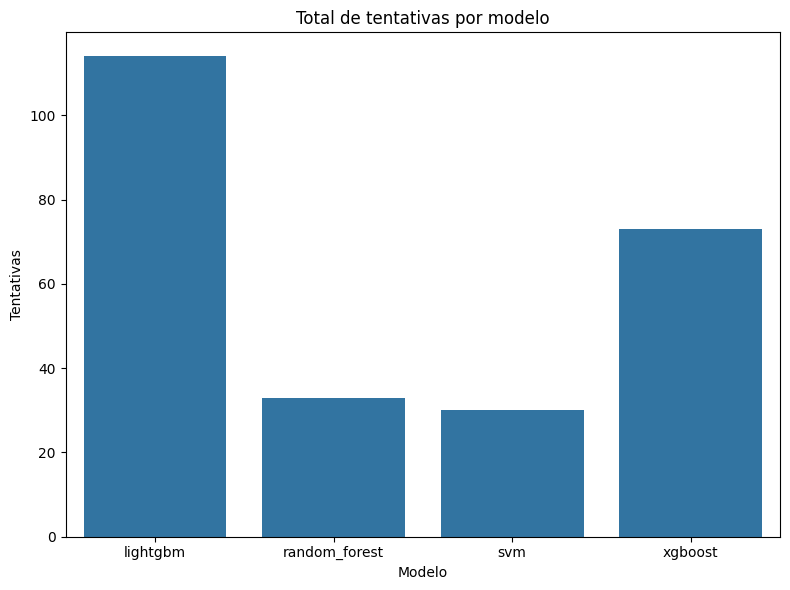

In [8]:
# Total de trials por modelo
total_trials = (df_metrics.groupby("params_model_name").size().reset_index(name="total_trials"))

plt.figure(figsize=(8, 6))
sns.barplot(data=total_trials,x="params_model_name",y="total_trials",)
plt.title("Total de tentativas por modelo")
plt.xlabel("Modelo")
plt.ylabel("Tentativas")
plt.tight_layout()
plt.show()

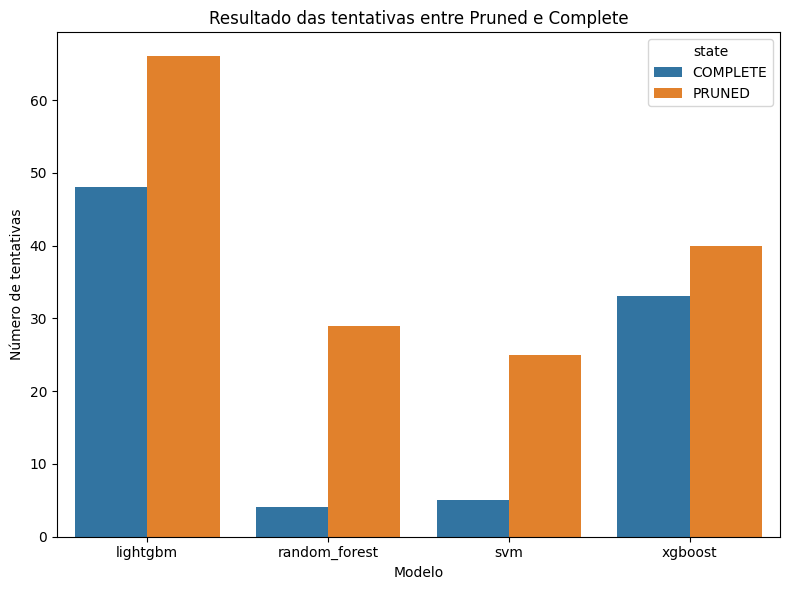

In [9]:
# Gráfico das tentativas de modelos completas e abortadas
counts_state = df_metrics.groupby(["params_model_name", "state"]).size().reset_index(name="count")

plt.figure(figsize=(8, 6))
sns.barplot(data=counts_state,x="params_model_name",y="count",hue="state",)
plt.title("Resultado das tentativas entre Pruned e Complete")
plt.xlabel("Modelo")
plt.ylabel("Número de tentativas")
plt.tight_layout()
plt.show()

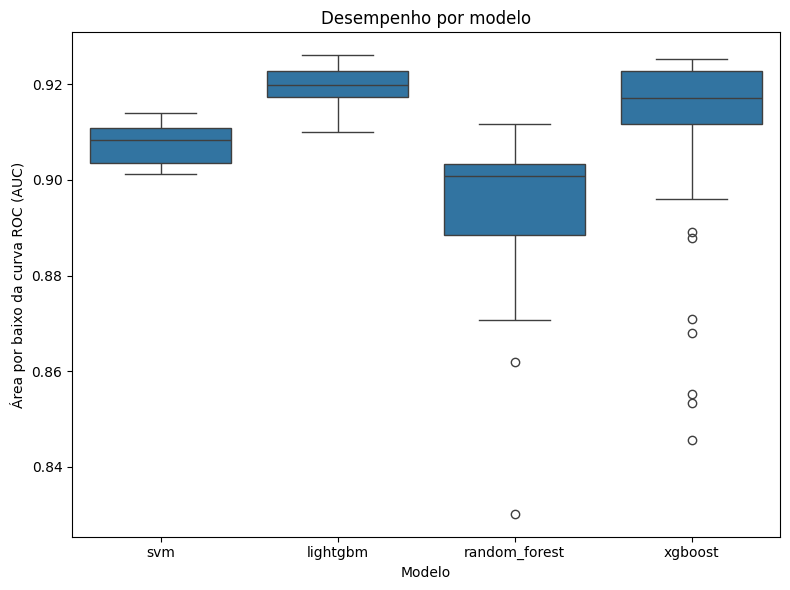

In [10]:
# Distribuição de performance (value) por modelo
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_metrics, x="params_model_name", y="value")
plt.title("Desempenho por modelo")
plt.xlabel("Modelo")
plt.ylabel("Área por baixo da curva ROC (AUC)")
plt.tight_layout()
plt.show()

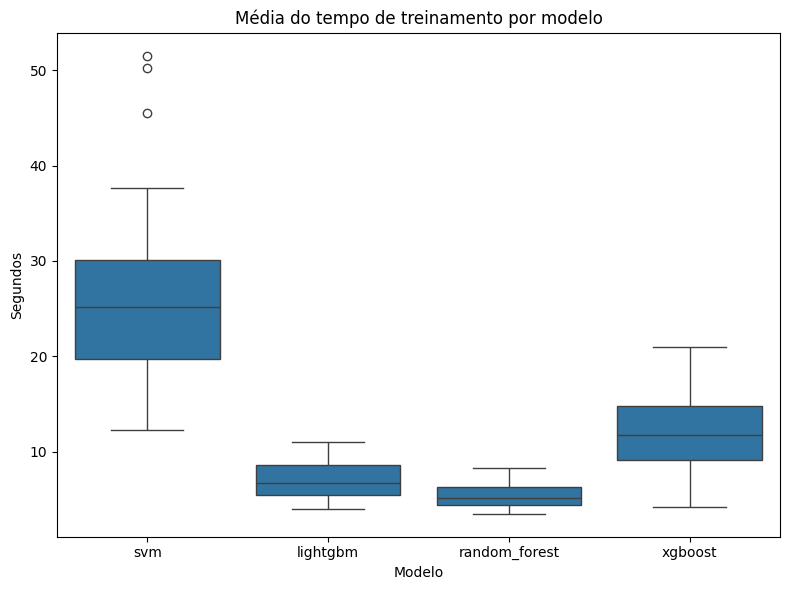

In [11]:
# Duração média de treino por modelo
df_metrics["duration_sec"] = pd.to_timedelta(df_metrics["duration"]).dt.total_seconds()
mean_duration = df_metrics.groupby("params_model_name")["duration_sec"].mean().reset_index()

# Distribuição do tempo de processamento por modelo

plt.figure(figsize=(8, 6))
sns.boxplot(data=df_metrics, x="params_model_name", y="duration_sec")
plt.title("Média do tempo de treinamento por modelo")
plt.xlabel("Modelo")
plt.ylabel("Segundos")
plt.tight_layout()
plt.show()

## Treinamento do modelo final

In [12]:
df_hyper =pd.DataFrame(df_results['hyperparameters'].to_list())
df_hyper

NameError: name 'df_results' is not defined

In [43]:
final_params=df_hyper.iloc[:,1:].median().to_dict()
final_params

{'n_estimators': 27.0,
 'learning_rate': 0.2380936275114841,
 'max_depth': 8.0,
 'subsample': 0.7386563518227348,
 'colsample_bytree': 0.5836868017188486}

{'n_estimators': 27.0,
 'learning_rate': 0.2380936275114841,
 'max_depth': 8.0,
 'subsample': 0.7386563518227348,
 'colsample_bytree': 0.5836868017188486}

In [42]:
def cast_params(params: dict) -> dict:
    p = dict(params)  # cópia

    # chaves que devem ser int no LightGBM
    int_keys = {
        "n_estimators", "num_iterations",
        "max_depth", "num_leaves",
        "min_child_samples", "min_data_in_leaf",
        "max_bin",
        "bagging_freq",
    }

    for k in list(p.keys()):
        if k in int_keys and p[k] is not None and not (isinstance(p[k], bool)):
            p[k] = int(round(float(p[k])))

    # max_depth: LightGBM aceita -1 como "sem limite"
    if "max_depth" in p and p["max_depth"] is not None:
        p["max_depth"] = int(p["max_depth"])

    return p

final_params = cast_params(final_params)
final_params

{'n_estimators': 27,
 'learning_rate': 0.2380936275114841,
 'max_depth': 8,
 'subsample': 0.7386563518227348,
 'colsample_bytree': 0.5836868017188486}

{'n_estimators': 27,
 'learning_rate': 0.2380936275114841,
 'max_depth': 8,
 'subsample': 0.7386563518227348,
 'colsample_bytree': 0.5836868017188486}

In [41]:
# Dicionário base para reconstrução
models = {
    'RandomForest': RandomForestClassifier(random_state=42),
    'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42),
    'LightGBM': lgb.LGBMClassifier(random_state=42),
    'SVM': CalibratedClassifierCV(LinearSVC( random_state=42))
}


In [40]:
# Reconstruir modelo
final_model = models['LightGBM']
final_model.set_params(**final_params)

cat_cols, num_cols = get_feature_types(X_data)

final_pipeline = build_pipeline(final_model, cat_cols, num_cols)

### Avaliando modelo final

## Interpretabilidade: importância de variáveis após pré-processamento (OHE) e mapeamento para colunas originais

Modelos treinados sobre pipelines com `ColumnTransformer` e `OneHotEncoder` operam em um espaço de features
expandido (múltiplas colunas por variável categórica). Para manter interpretabilidade, esta seção:
1) recupera os nomes finais das features no espaço transformado,
2) extrai uma medida de importância/coeficiente do modelo treinado,
3) mapeia as features transformadas de volta para as variáveis originais,
4) consolida a importância no nível da coluna original.

Isso permite reportar resultados em termos das variáveis do dataset original, facilitando comunicação e análise.


### Extração de nomes das features pós-`ColumnTransformer`

A função `get_feature_names` reconstrói o vetor de nomes de features gerado após o pré-processamento,
incluindo:
- variáveis numéricas (após imputação/escala),
- variáveis categóricas expandidas via One-Hot Encoding,
- e, opcionalmente, colunas passadas via `remainder='passthrough'`.

Essa etapa é necessária porque, após o `fit_transform`, a matriz final perde o vínculo direto com o nome
das colunas originais, e a identificação correta das features é condição para qualquer análise de importância.


In [39]:
# 1. FUNÇÃO PARA EXTRAIR NOMES DAS FEATURES PÓS-OHE
def get_feature_names(column_transformer):
    """
    Extrai nomes finais das features após ColumnTransformer,
    incluindo OneHotEncoder e transformações numéricas.
    """
    output_features = []

    for name, transformer, features in column_transformer.transformers_:

        # Caso 'remainder=passthrough'
        if name == "remainder":
            output_features.extend(features)
            continue

        # Transformers com get_feature_names_out() (OneHotEncoder, etc)
        if hasattr(transformer, "get_feature_names_out"):
            try:
                names = transformer.get_feature_names_out(features)
            except:
                names = transformer.get_feature_names_out()
            output_features.extend(names)

        # Caso não possua o método
        else:
            output_features.extend(features)

    return output_features


### Mapeamento para variáveis originais via fuzzy matching

Após o One-Hot Encoding, uma mesma variável categórica pode gerar dezenas de colunas com nomes derivados.
Para consolidar resultados no nível da variável original, é aplicado *fuzzy matching* entre o nome da feature
pós-OHE e a lista de variáveis originais de interesse (`features_explicativas`).

O objetivo do fuzzy matching é lidar com diferenças de sufixos/prefixos criados pelo encoding e manter
um vínculo prático entre “feature transformada” e “coluna original”. O parâmetro `threshold`
controla o quão estrita é a correspondência:
- valores maiores reduzem falsos positivos (match errado),
- valores menores aumentam cobertura, mas elevam risco de mapeamentos incorretos.

Após o matching, apenas features com correspondência válida são mantidas para agregação.


In [38]:
def fuzzy_match_original(feature_name, triage_features, threshold=70):
    """
    Realiza fuzzy matching buscando qual variável ORIGINAL
    está mais relacionada com o nome da feature pós-OHE.
    """
    best_match, score, _ = process.extractOne(
        feature_name,
        triage_features,
        scorer=fuzz.partial_ratio
    )
    return best_match if score >= threshold else None



## Validação cruzada externa: avaliação e interpretabilidade por fold

Nesta etapa, aplica-se uma `StratifiedKFold` externa para avaliar o desempenho do pipeline e também
inspecionar a importância de variáveis por fold. A estratificação preserva a proporção das classes,
reduzindo instabilidade em bases desbalanceadas.

Para cada fold:
- o pipeline final é treinado no conjunto de treino,
- a importância das features é extraída do modelo treinado,
- as importâncias são consolidadas no nível da variável original e visualizadas,
- e o desempenho é medido no conjunto de teste com métricas e curvas.



  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 33022, number of negative: 33022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.177421 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41480
[LightGBM] [Info] Number of data points in the train set: 66044, number of used features: 338
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


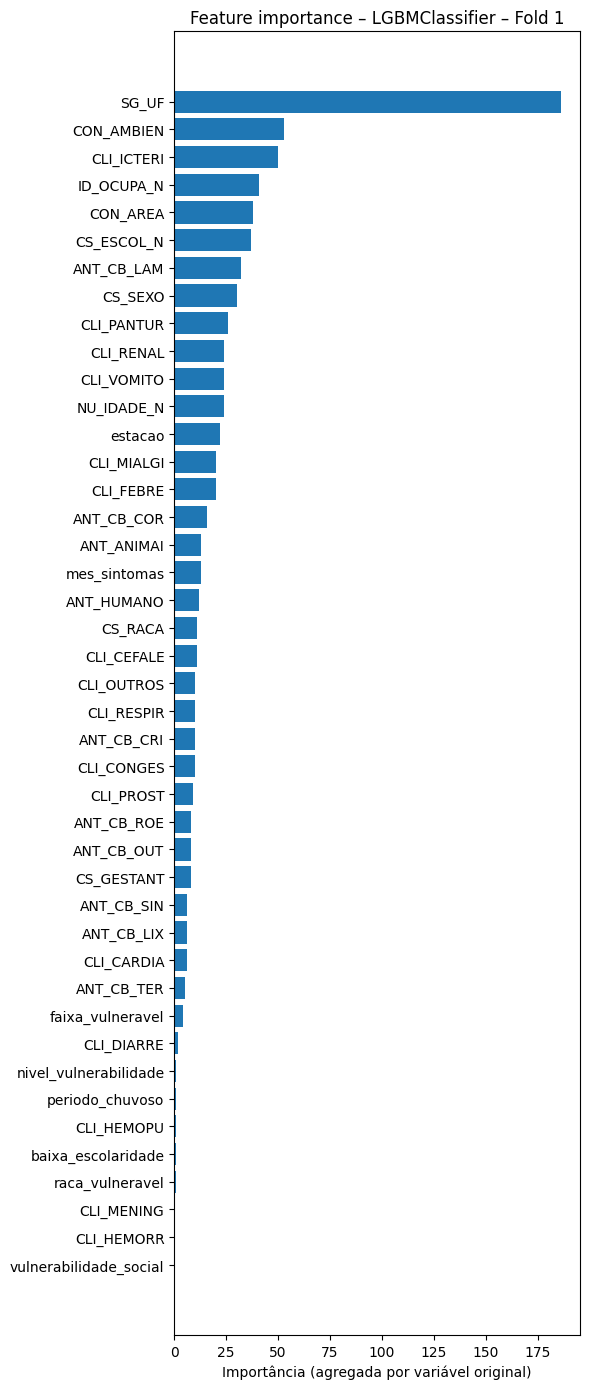

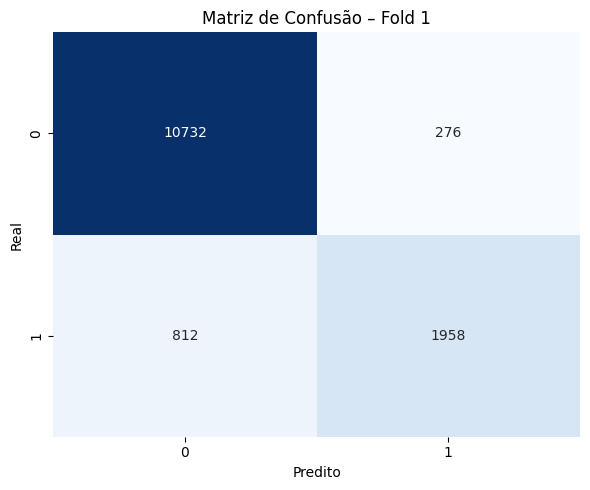

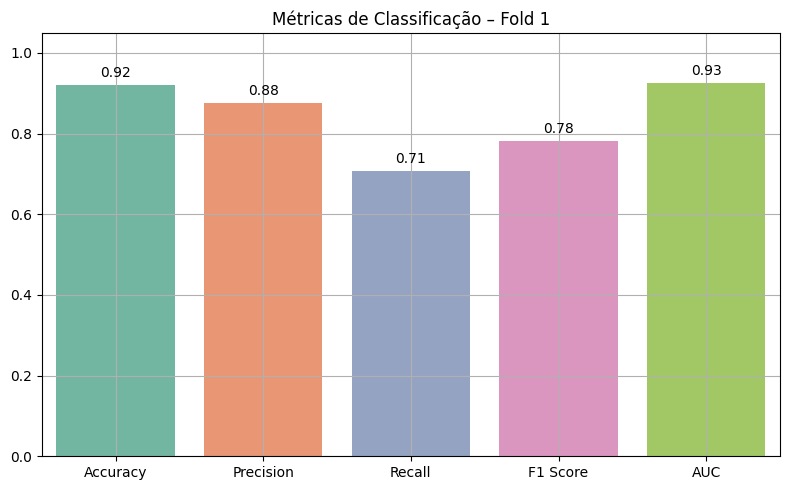

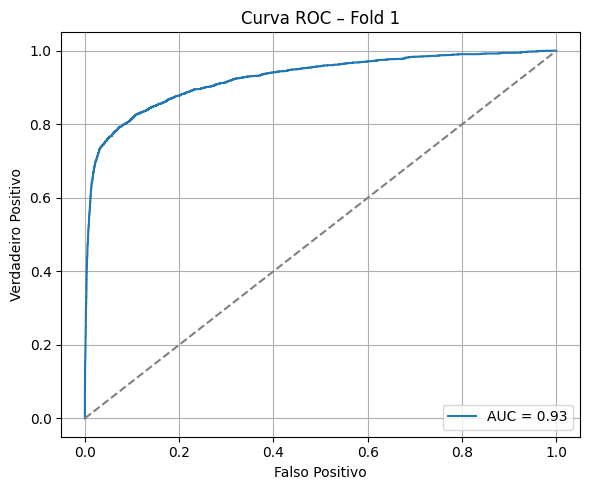

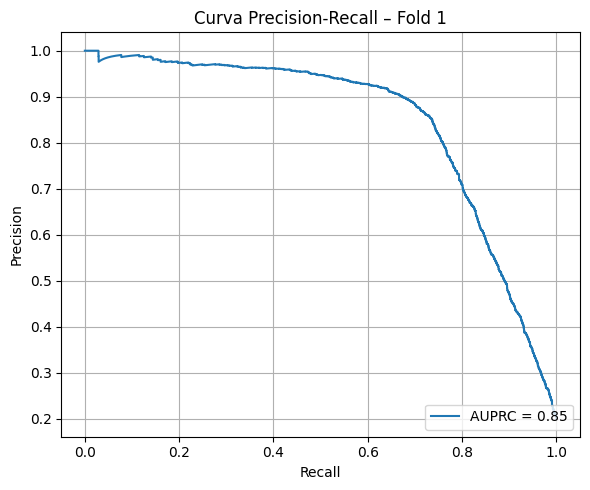


  Fold Externo 2/4
[LightGBM] [Info] Number of positive: 33022, number of negative: 33022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.175804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41269
[LightGBM] [Info] Number of data points in the train set: 66044, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


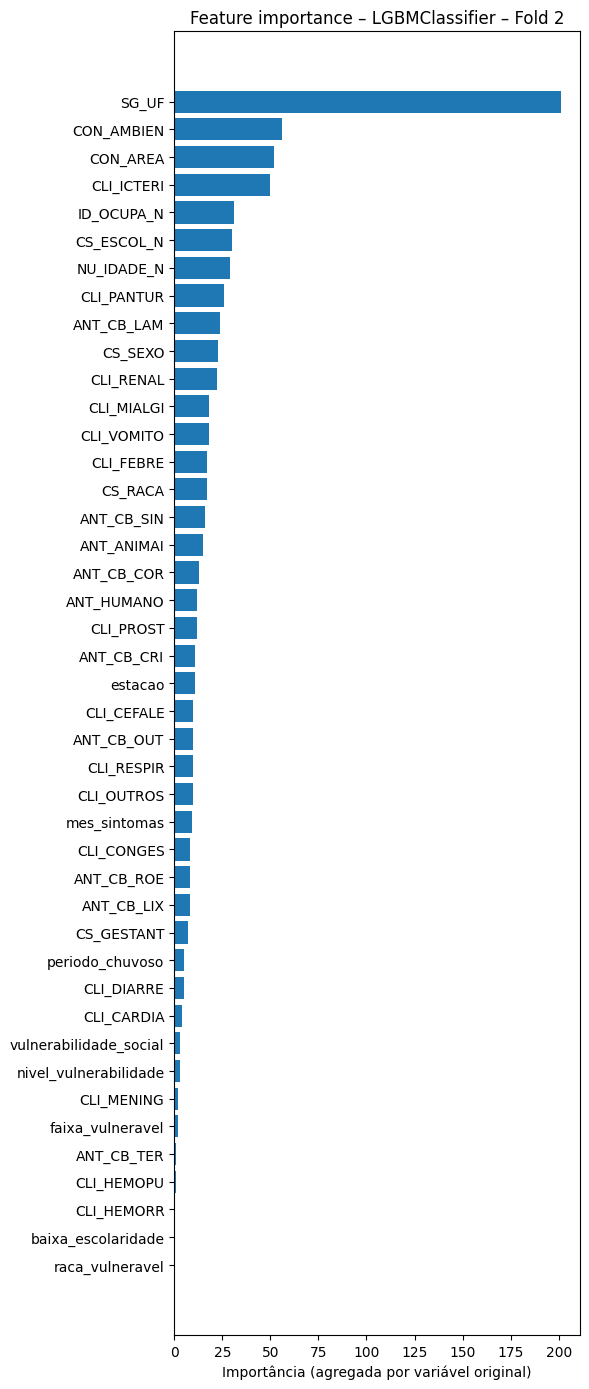

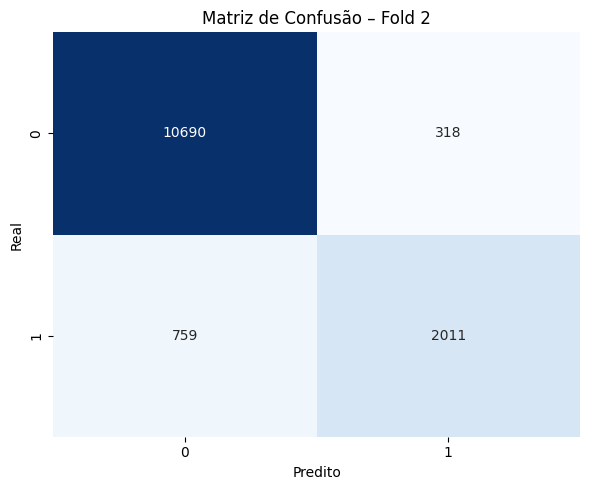

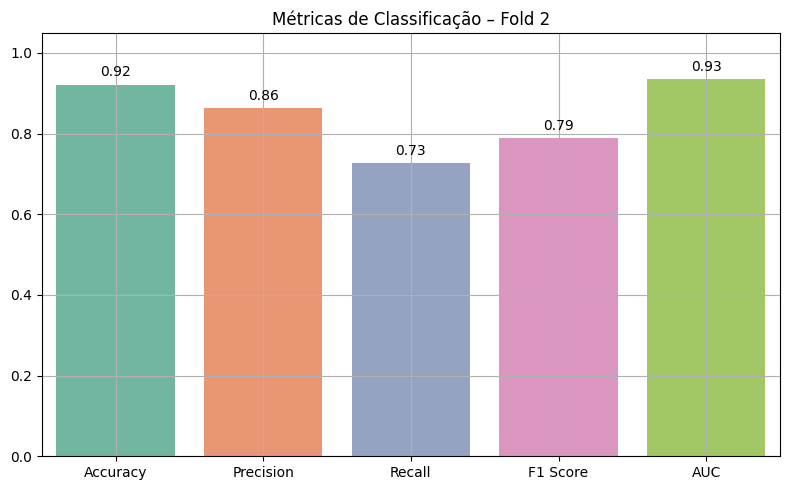

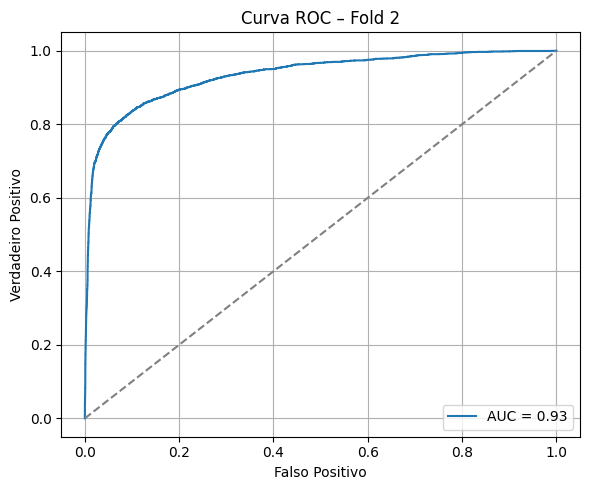

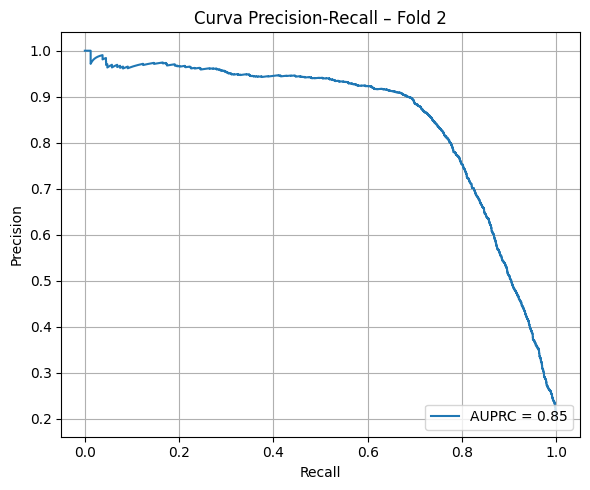


  Fold Externo 3/4
[LightGBM] [Info] Number of positive: 33023, number of negative: 33023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.171773 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41126
[LightGBM] [Info] Number of data points in the train set: 66046, number of used features: 336
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


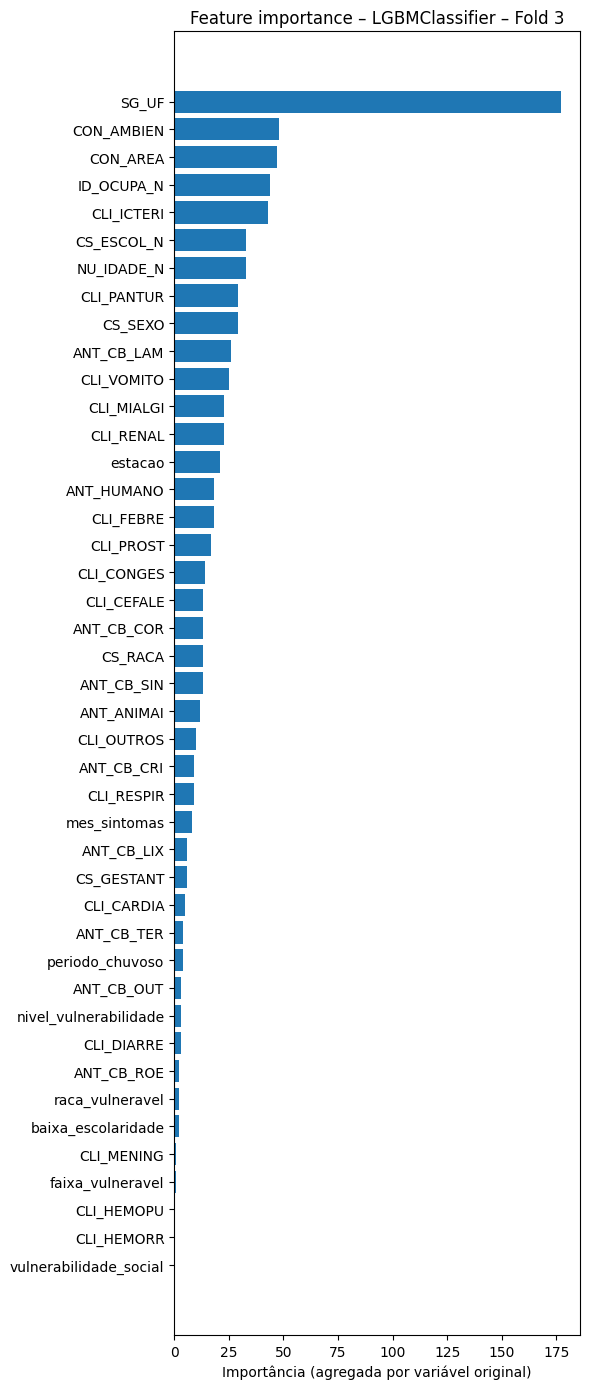

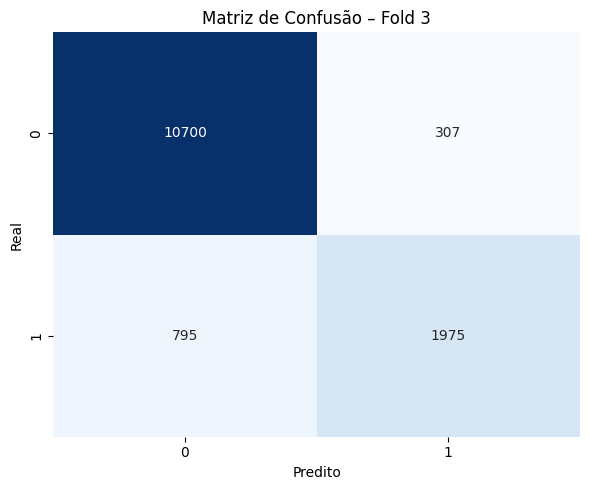

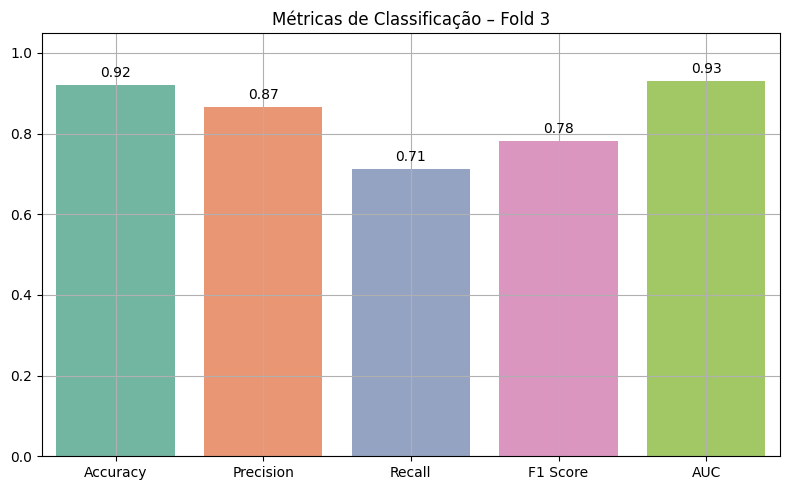

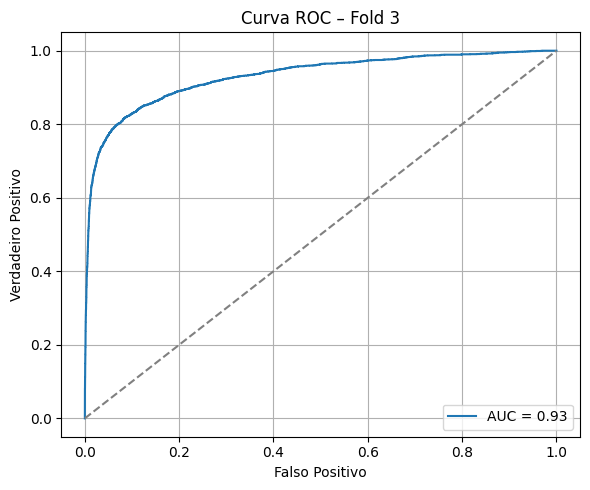

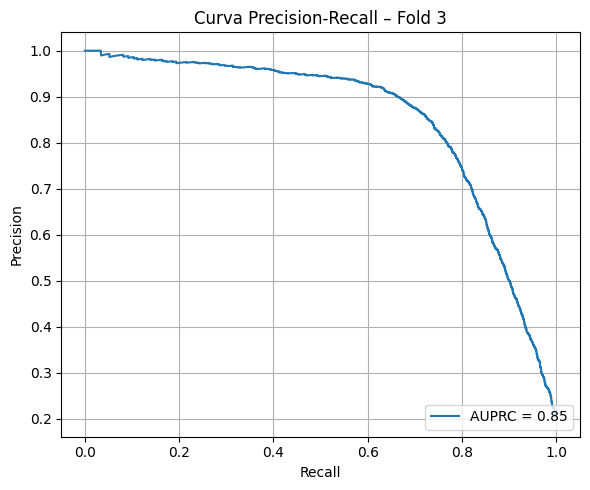


  Fold Externo 4/4
[LightGBM] [Info] Number of positive: 33023, number of negative: 33023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.193962 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41338
[LightGBM] [Info] Number of data points in the train set: 66046, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


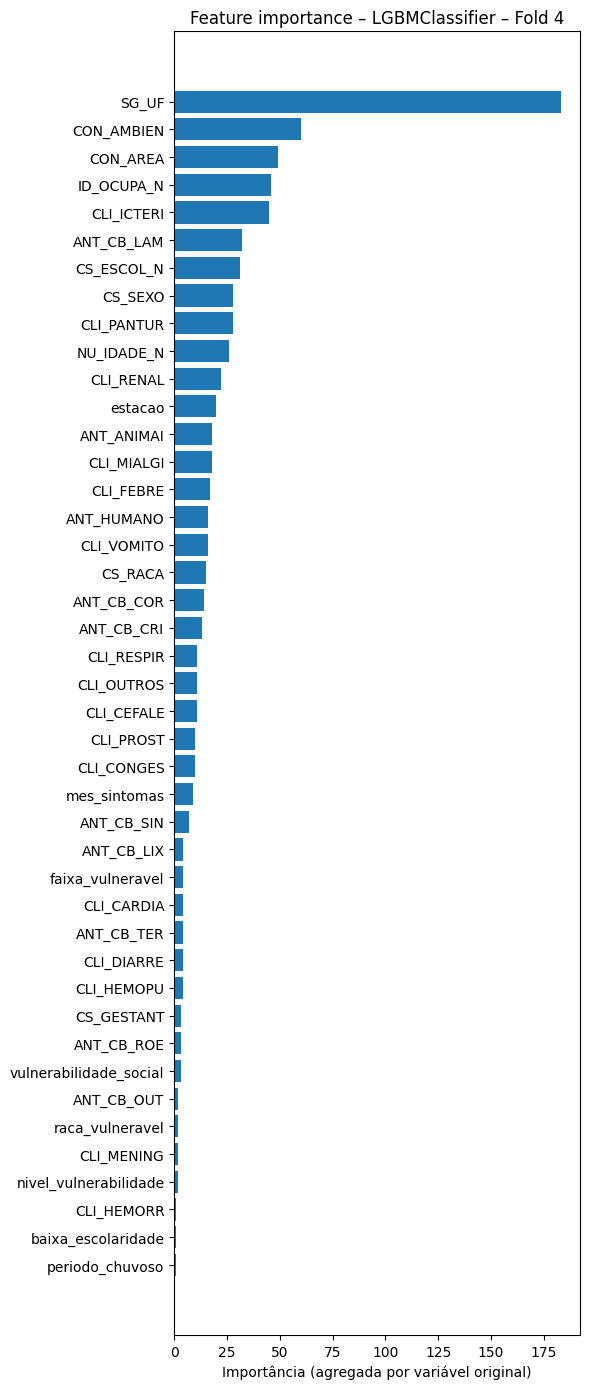

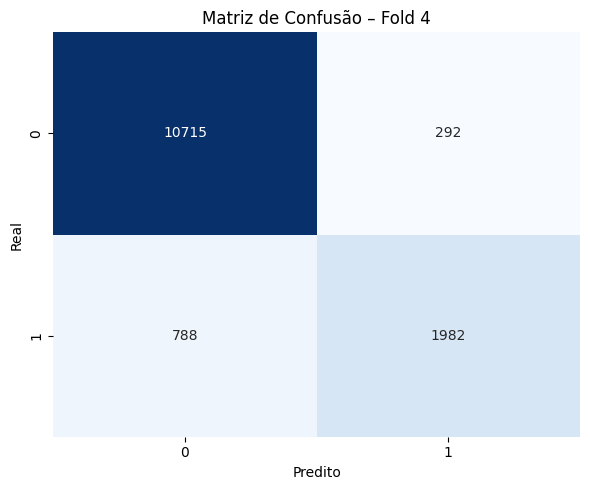

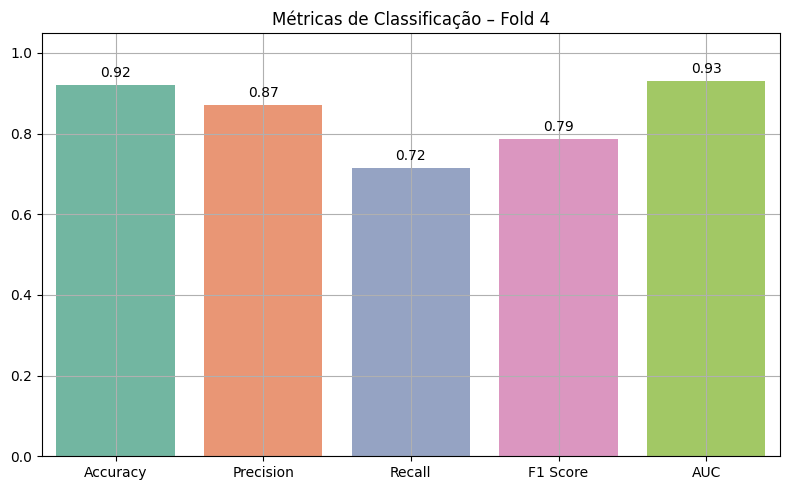

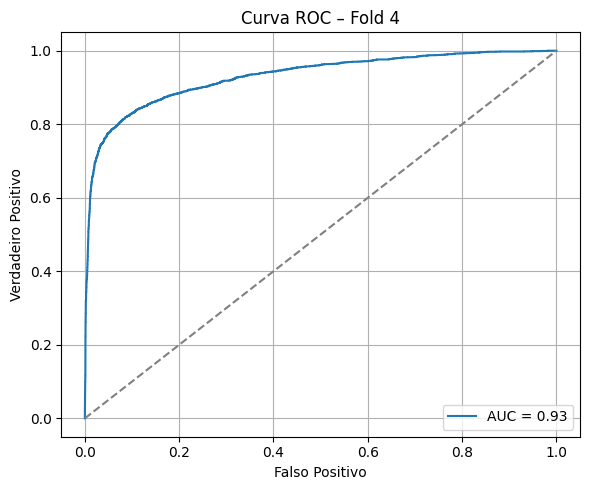

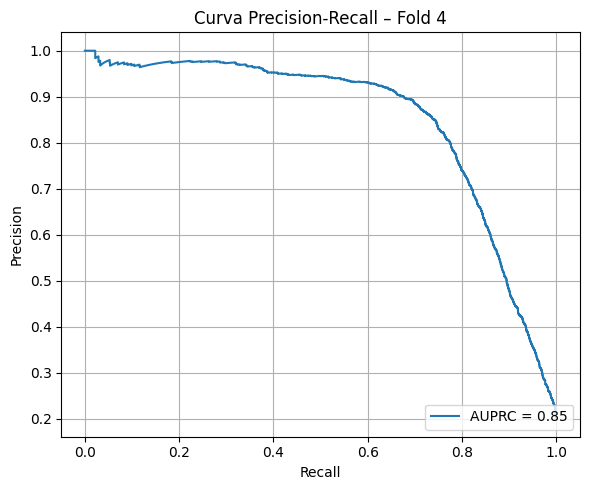



MÉTRICAS POR FOLD


,fold,n_train,n_test,accuracy,precision,recall,f1,auc,tn,fp,fn,tp,model_name
0,1,41332,13778,0.921034,0.876455,0.706859,0.782574,0.926357,10732,276,812,1958,LGBMClassifier
1,2,41332,13778,0.921832,0.863461,0.725993,0.788782,0.934471,10690,318,759,2011,LGBMClassifier
2,3,41333,13777,0.920012,0.865469,0.712996,0.781869,0.930768,10700,307,795,1975,LGBMClassifier
3,4,41333,13777,0.921608,0.871592,0.715523,0.785884,0.930353,10715,292,788,1982,LGBMClassifier




RESUMO GERAL DAS MÉTRICAS (média e desvio padrão)


,metric,mean,std
0,accuracy,0.921121,0.000813
1,precision,0.869244,0.005922
2,recall,0.715343,0.007978
3,f1,0.784777,0.003193
4,auc,0.930487,0.003318




TOP 20 FEATURES POR FOLD (agregadas em variável original)


,feature,importance,fold,rank_in_fold
0,SG_UF,186,1,1
1,CON_AMBIEN,53,1,2
2,CLI_ICTERI,50,1,3
3,ID_OCUPA_N,41,1,4
4,CON_AREA,38,1,5
...,...,...,...,...
75,ANT_HUMANO,16,4,16
76,CLI_VOMITO,16,4,17
77,CS_RACA,15,4,18
78,ANT_CB_COR,14,4,19




TOP 30 FEATURES GERAIS (média/std das importâncias + estabilidade via rank)


,feature,mean_importance,std_importance,folds_present,mean_rank,std_rank
0,SG_UF,186.75,10.210289,4,1.000,0.000000
1,CON_AMBIEN,54.25,5.057997,4,2.000,0.000000
2,CLI_ICTERI,47.00,3.559026,4,4.250,0.957427
3,CON_AREA,46.50,6.027714,4,3.500,1.000000
4,ID_OCUPA_N,40.50,6.658328,4,4.250,0.500000
5,CS_ESCOL_N,32.75,3.095696,4,6.375,0.478714
6,ANT_CB_LAM,28.50,4.123106,4,8.000,1.825742
7,NU_IDADE_N,28.00,3.915780,4,8.625,2.212653
8,CS_SEXO,27.50,3.109126,4,8.750,0.866025
9,CLI_PANTUR,27.25,1.500000,4,8.500,0.408248



  Fold Externo 1/4
[LightGBM] [Info] Number of positive: 33022, number of negative: 33022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.186901 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41480
[LightGBM] [Info] Number of data points in the train set: 66044, number of used features: 338
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


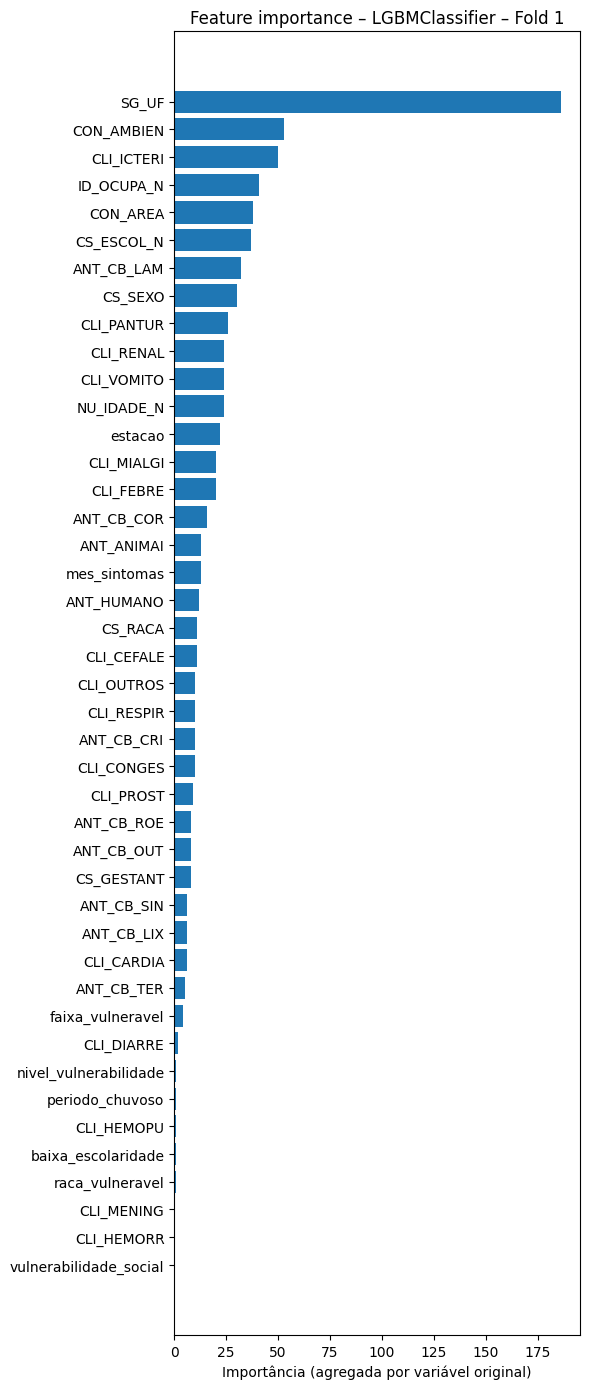

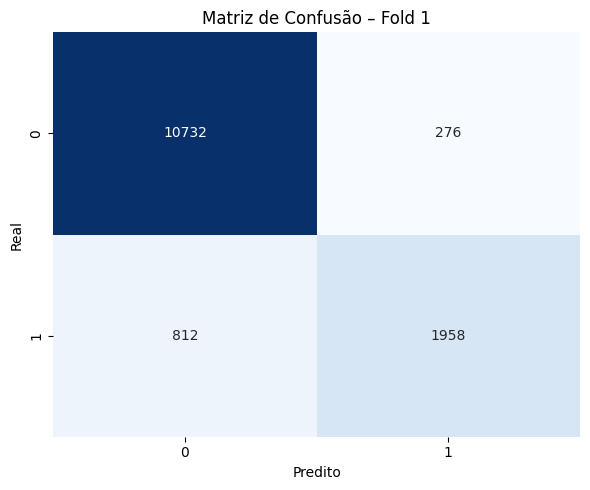

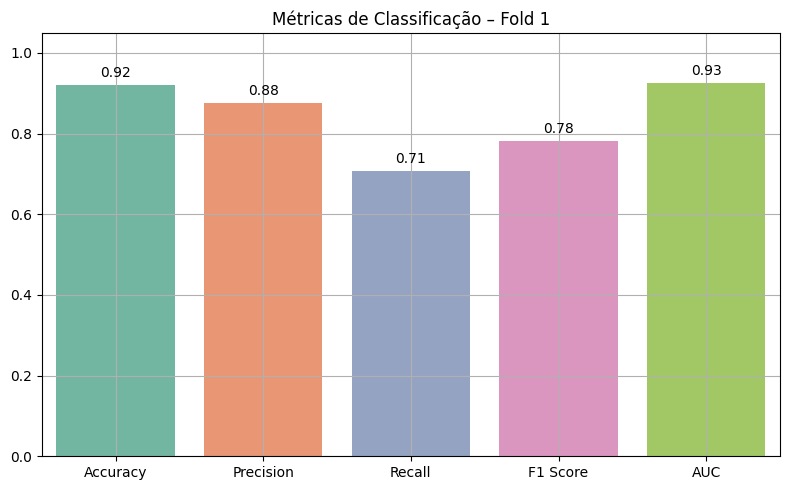

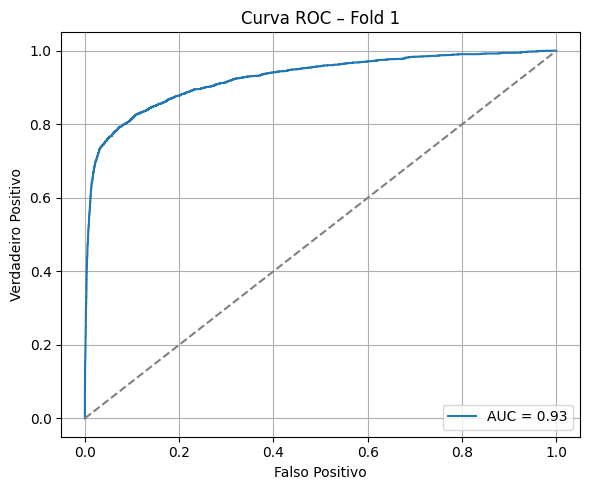

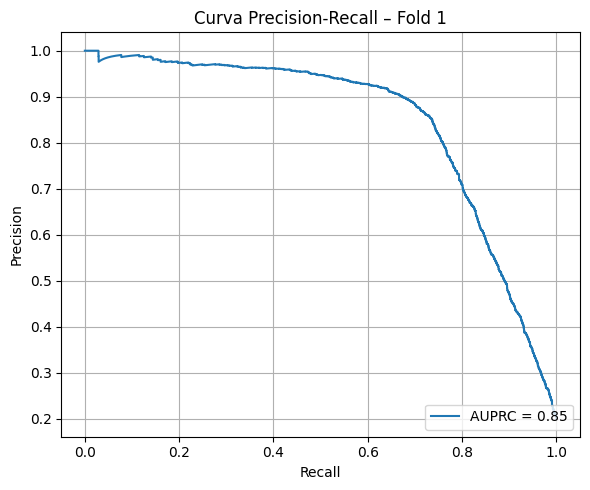


  Fold Externo 2/4
[LightGBM] [Info] Number of positive: 33022, number of negative: 33022
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.174256 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41269
[LightGBM] [Info] Number of data points in the train set: 66044, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


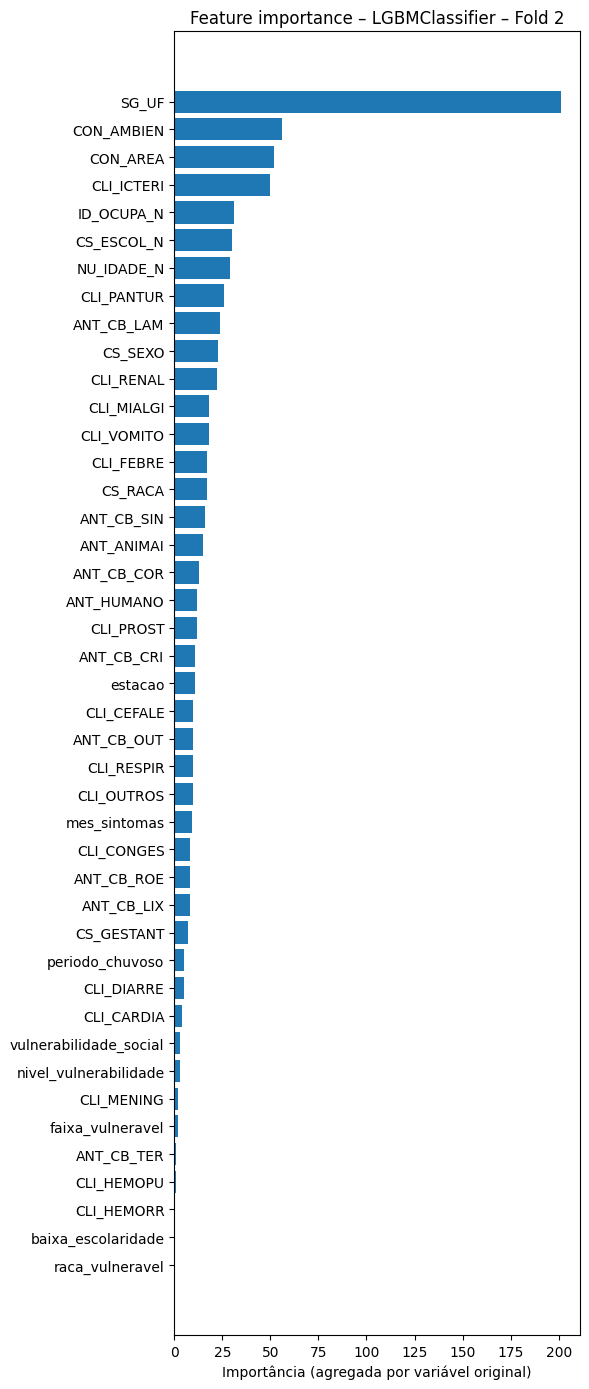

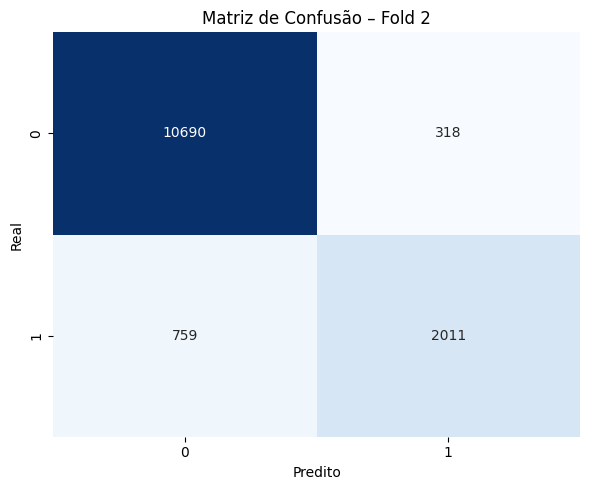

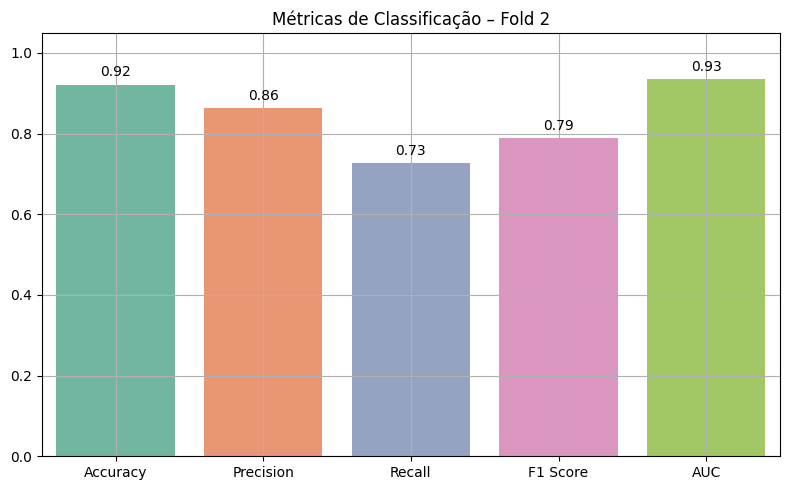

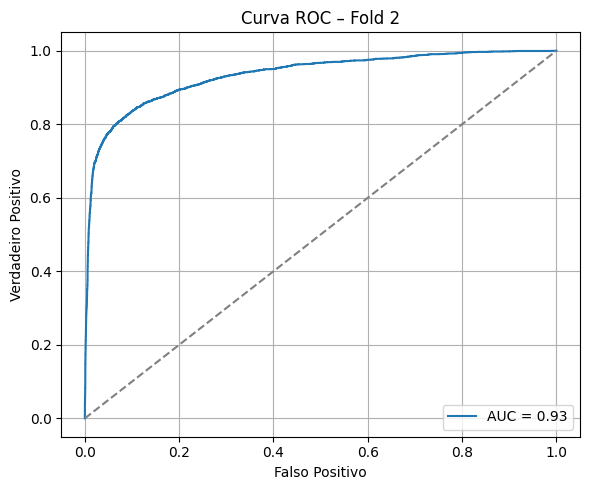

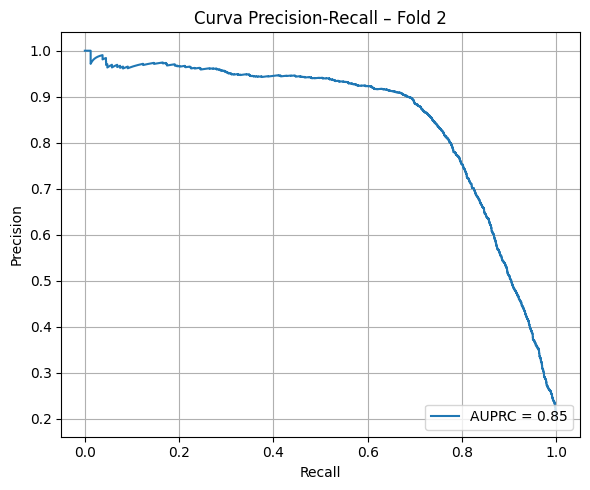


  Fold Externo 3/4
[LightGBM] [Info] Number of positive: 33023, number of negative: 33023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.186266 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41126
[LightGBM] [Info] Number of data points in the train set: 66046, number of used features: 336
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


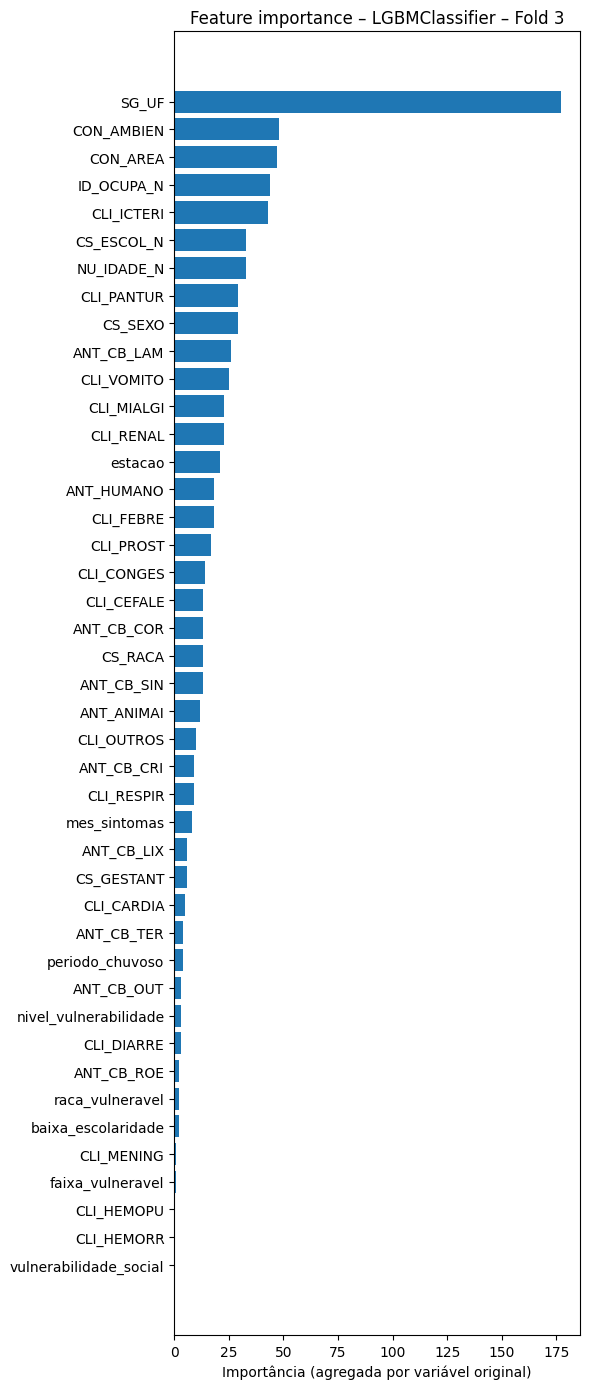

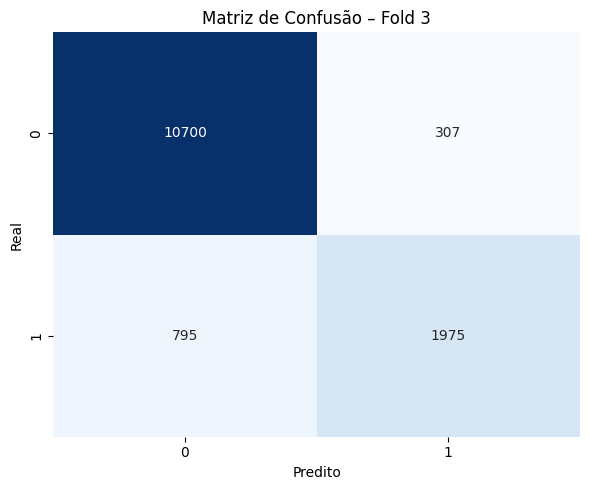

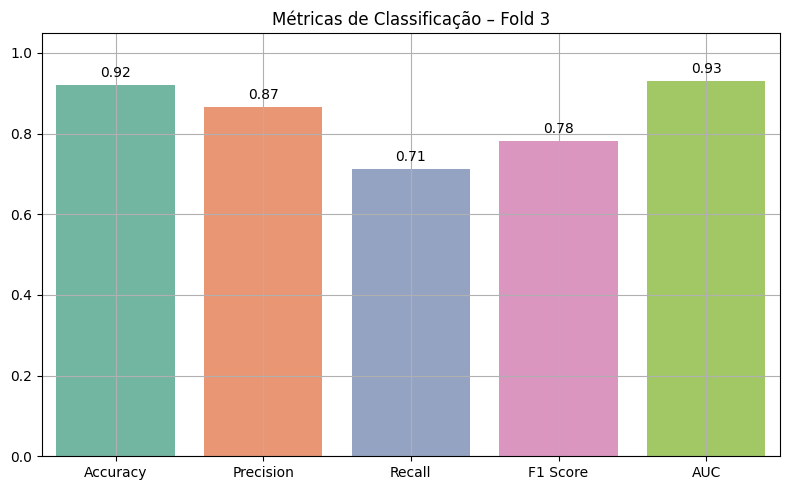

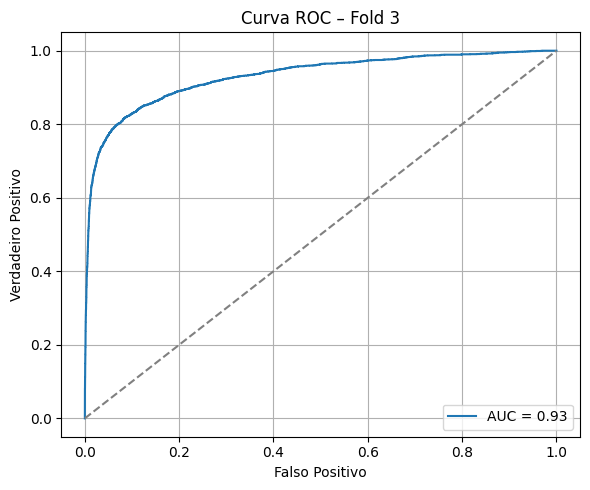

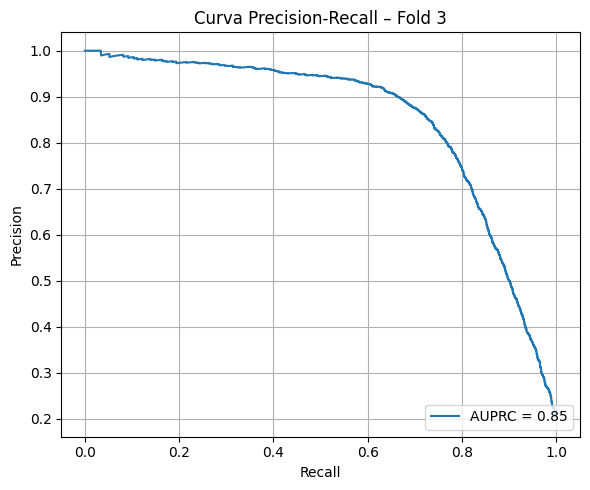


  Fold Externo 4/4
[LightGBM] [Info] Number of positive: 33023, number of negative: 33023
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.183207 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 41338
[LightGBM] [Info] Number of data points in the train set: 66046, number of used features: 337
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000


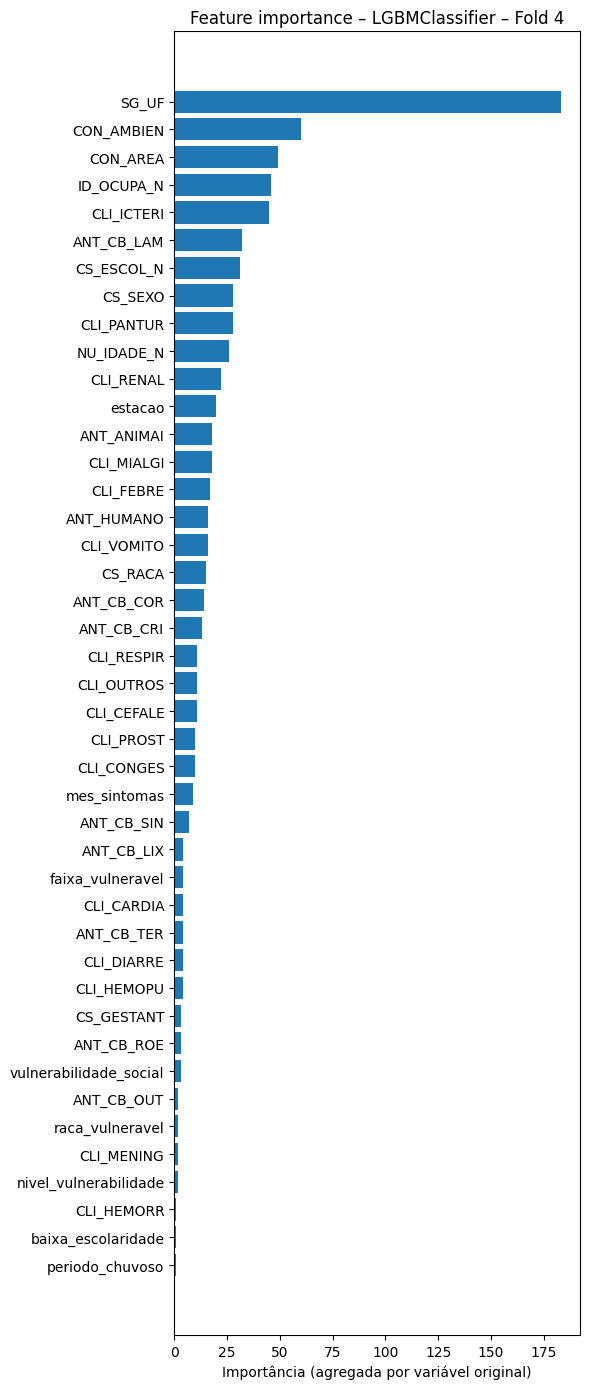

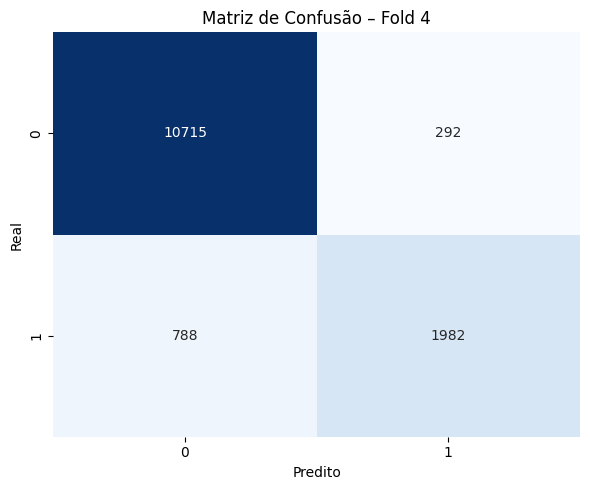

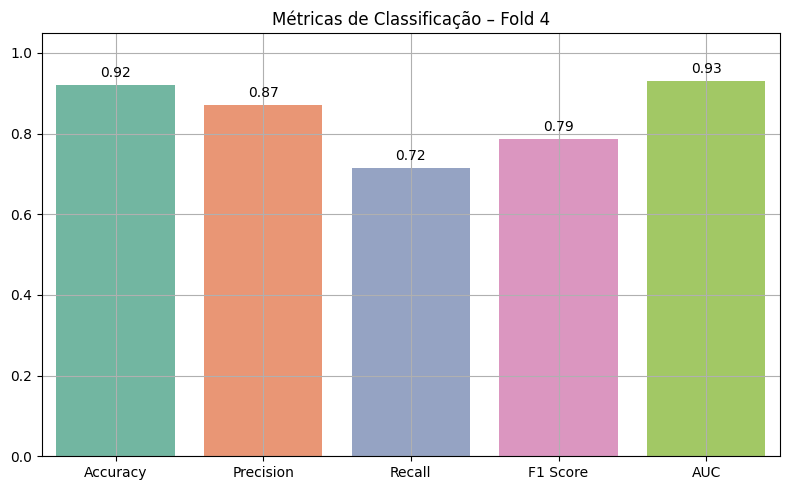

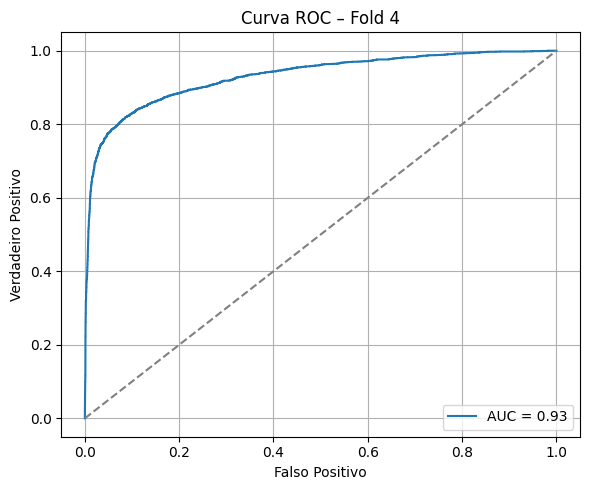

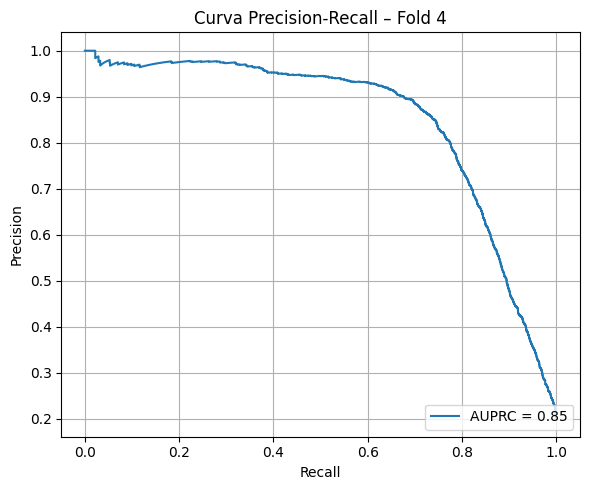



MÉTRICAS POR FOLD


,fold,n_train,n_test,accuracy,precision,recall,f1,auc,tn,fp,fn,tp,model_name
0,1,41332,13778,0.921034,0.876455,0.706859,0.782574,0.926357,10732,276,812,1958,LGBMClassifier
1,2,41332,13778,0.921832,0.863461,0.725993,0.788782,0.934471,10690,318,759,2011,LGBMClassifier
2,3,41333,13777,0.920012,0.865469,0.712996,0.781869,0.930768,10700,307,795,1975,LGBMClassifier
3,4,41333,13777,0.921608,0.871592,0.715523,0.785884,0.930353,10715,292,788,1982,LGBMClassifier




RESUMO GERAL DAS MÉTRICAS (média e desvio padrão)


,metric,mean,std
0,accuracy,0.921121,0.000813
1,precision,0.869244,0.005922
2,recall,0.715343,0.007978
3,f1,0.784777,0.003193
4,auc,0.930487,0.003318




TOP 20 FEATURES POR FOLD (agregadas em variável original)


,feature,importance,fold,rank_in_fold
0,SG_UF,186,1,1
1,CON_AMBIEN,53,1,2
2,CLI_ICTERI,50,1,3
3,ID_OCUPA_N,41,1,4
4,CON_AREA,38,1,5
...,...,...,...,...
75,ANT_HUMANO,16,4,16
76,CLI_VOMITO,16,4,17
77,CS_RACA,15,4,18
78,ANT_CB_COR,14,4,19




TOP 30 FEATURES GERAIS (média/std das importâncias + estabilidade via rank)


,feature,mean_importance,std_importance,folds_present,mean_rank,std_rank
0,SG_UF,186.75,10.210289,4,1.000,0.000000
1,CON_AMBIEN,54.25,5.057997,4,2.000,0.000000
2,CLI_ICTERI,47.00,3.559026,4,4.250,0.957427
3,CON_AREA,46.50,6.027714,4,3.500,1.000000
4,ID_OCUPA_N,40.50,6.658328,4,4.250,0.500000
5,CS_ESCOL_N,32.75,3.095696,4,6.375,0.478714
6,ANT_CB_LAM,28.50,4.123106,4,8.000,1.825742
7,NU_IDADE_N,28.00,3.915780,4,8.625,2.212653
8,CS_SEXO,27.50,3.109126,4,8.750,0.866025
9,CLI_PANTUR,27.25,1.500000,4,8.500,0.408248


In [37]:
# =========================
# Parâmetros
# =========================
n_splits = 4
top_k = 20        # top features por fold (para tabelas)
top_overall = 30  # top features gerais (para tabela final)

outer_cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

# =========================
# Coletores (tabelas)
# =========================
fold_metrics = []          # 1 linha por fold com métricas + conf matrix flatten
fold_top_features = []     # top_k features por fold (já agrupadas em original_var)
all_features_long = []     # todas features (agrupadas) por fold -> resumo geral

fold = 1
for train_idx, test_idx in outer_cv.split(X_data, y_data):

    print(f"\n==============================")
    print(f"  Fold Externo {fold}/{n_splits}")
    print(f"==============================")

    X_train, X_test = X_data.iloc[train_idx], X_data.iloc[test_idx]
    y_train, y_test = y_data.iloc[train_idx], y_data.iloc[test_idx]

    # =========================
    # 1) Fit do pipeline no fold
    # =========================
    final_pipeline.fit(X_train, y_train)

    # =========================
    # 2) Importâncias
    # =========================
    model = final_pipeline.named_steps["model"]

    if hasattr(model, "feature_importances_"):
        importances = model.feature_importances_
    elif hasattr(model, "coef_"):
        coef = model.coef_
        # binary: (n_features,) ou (1, n_features)
        # multiclass: (n_classes, n_features) -> agregamos por média do abs
        importances = coef.ravel() if coef.ndim == 1 else np.mean(np.abs(coef), axis=0)
    else:
        raise ValueError("Este modelo não possui atributo de importância (feature_importances_ ou coef_).")

    # =========================
    # 3) Nomes pós-preprocessamento
    # =========================
    preproc = final_pipeline.named_steps["preprocessor"]
    feature_names = get_feature_names(preproc)

    if len(feature_names) != len(importances):
        raise ValueError(
            f"Mismatch: {len(feature_names)} nomes de features vs {len(importances)} importâncias. "
            "Cheque get_feature_names() / preprocessor."
        )

    df_imp = pd.DataFrame({"feature": feature_names, "importance": importances})

    # =========================
    # 4) Fuzzy match para variáveis originais e agregação
    # =========================
    df_imp["original_var"] = df_imp["feature"].apply(lambda x: fuzzy_match_original(x, triage_features))
    df_imp = df_imp[df_imp["original_var"].notna()].copy()

    df_grouped = (
        df_imp.groupby("original_var", as_index=False)["importance"]
              .sum()
              .sort_values("importance", ascending=False)
              .rename(columns={"original_var": "feature"})
              .reset_index(drop=True)
    )

    # =========================
    # 4.1) Plot: Feature importance (por fold)
    # =========================
    plt.figure(figsize=(6, 14))
    plt.barh(df_grouped["feature"][::-1], df_grouped["importance"][::-1])
    plt.xlabel("Importância (agregada por variável original)")
    plt.title(f"Feature importance – {type(model).__name__} – Fold {fold}")
    plt.tight_layout()
    plt.show()

    # guarda top features do fold (top_k)
    df_top = df_grouped.head(top_k).copy()
    df_top["fold"] = fold
    df_top["rank_in_fold"] = np.arange(1, len(df_top) + 1)
    fold_top_features.append(df_top)

    # guarda TODAS as features agregadas do fold (para resumo geral)
    df_grouped_long = df_grouped.copy()
    df_grouped_long["fold"] = fold
    all_features_long.append(df_grouped_long)

    # =========================
    # 5) Predições / probabilidades
    # =========================
    y_pred = final_pipeline.predict(X_test)

    y_proba = None
    if hasattr(final_pipeline, "predict_proba"):
        try:
            y_proba = final_pipeline.predict_proba(X_test)[:, 1]
        except Exception:
            y_proba = None

    # =========================
    # 6) Matriz de confusão (plot)
    # =========================
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f"Matriz de Confusão – Fold {fold}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    # =========================
    # 7) Métricas (plot + tabela)
    # =========================
    metrics_dict_plot = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1 Score": f1_score(y_test, y_pred, zero_division=0),
        "AUC": roc_auc_score(y_test, y_proba) if y_proba is not None else np.nan
    }

    plt.figure(figsize=(8, 5))
    sns.barplot(x=list(metrics_dict_plot.keys()), y=list(metrics_dict_plot.values()), palette="Set2")
    plt.ylim(0, 1.05)
    plt.title(f"Métricas de Classificação – Fold {fold}")
    for i, v in enumerate(metrics_dict_plot.values()):
        if np.isfinite(v):
            plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
        else:
            plt.text(i, 0.02, "NA", ha='center')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # salva métricas estruturadas (para df_metrics)
    fold_metrics.append({
        "fold": fold,
        "n_train": len(train_idx),
        "n_test": len(test_idx),
        "accuracy": metrics_dict_plot["Accuracy"],
        "precision": metrics_dict_plot["Precision"],
        "recall": metrics_dict_plot["Recall"],
        "f1": metrics_dict_plot["F1 Score"],
        "auc": metrics_dict_plot["AUC"],
        "tn": cm[0, 0], "fp": cm[0, 1], "fn": cm[1, 0], "tp": cm[1, 1],
        "model_name": type(model).__name__,
    })

    # =========================
    # 8) Curva ROC (plot)
    # =========================
    if y_proba is not None:
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        roc_auc = auc(fpr, tpr)

        plt.figure(figsize=(6, 5))
        plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
        plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
        plt.xlabel("Falso Positivo")
        plt.ylabel("Verdadeiro Positivo")
        plt.title(f"Curva ROC – Fold {fold}")
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    # =========================
    # 9) Curva Precision-Recall (plot)
    # =========================
    if y_proba is not None:
        precision, recall, _ = precision_recall_curve(y_test, y_proba)
        auprc_trap = auc(recall, precision)

        plt.figure(figsize=(6, 5))
        plt.plot(recall, precision, label=f"AUPRC = {auprc_trap:.2f}")
        plt.xlabel("Recall")
        plt.ylabel("Precision")
        plt.title(f"Curva Precision-Recall – Fold {fold}")
        plt.legend(loc='lower right')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

    fold += 1


# =========================
# 10) DF: métricas por fold
# =========================
df_metrics = pd.DataFrame(fold_metrics).sort_values("fold").reset_index(drop=True)

# resumo (média e desvio padrão) das métricas
metric_cols = ["accuracy", "precision", "recall", "f1", "auc"]
df_metrics_summary = (
    df_metrics[metric_cols]
    .agg(["mean", "std"])
    .T
    .rename(columns={"mean": "mean", "std": "std"})
    .reset_index()
    .rename(columns={"index": "metric"})
)

# =========================
# 11) DF: top features por fold
# =========================
df_top_by_fold = pd.concat(fold_top_features, ignore_index=True)

# =========================
# 12) DF: resumo geral das features (média/std + rank)
# =========================
df_all_features_long = pd.concat(all_features_long, ignore_index=True)

df_feature_summary = (
    df_all_features_long
    .groupby("feature", as_index=False)
    .agg(
        mean_importance=("importance", "mean"),
        std_importance=("importance", "std"),
        folds_present=("fold", "nunique"),
    )
)

# ranking médio por fold (quanto menor, mais importante)
df_ranks = (
    df_all_features_long
    .assign(rank_in_fold=lambda d: d.groupby("fold")["importance"].rank(ascending=False, method="average"))
)

df_rank_summary = (
    df_ranks.groupby("feature", as_index=False)
            .agg(mean_rank=("rank_in_fold", "mean"), std_rank=("rank_in_fold", "std"))
)

df_feature_summary = (
    df_feature_summary.merge(df_rank_summary, on="feature", how="left")
                      .sort_values(["mean_importance", "folds_present"], ascending=[False, False])
                      .reset_index(drop=True)
)

df_top_features_overall = df_feature_summary.head(top_overall).copy()

# =========================
# 13) OUTPUT final (tabelas)
# =========================
print("\n\n==============================")
print("MÉTRICAS POR FOLD")
print("==============================")
display(df_metrics)

print("\n\n==============================")
print("RESUMO GERAL DAS MÉTRICAS (média e desvio padrão)")
print("==============================")
display(df_metrics_summary)

print("\n\n==============================")
print(f"TOP {top_k} FEATURES POR FOLD (agregadas em variável original)")
print("==============================")
display(df_top_by_fold.sort_values(["fold", "rank_in_fold"]))

print("\n\n==============================")
print(f"TOP {top_overall} FEATURES GERAIS (média/std das importâncias + estabilidade via rank)")
print("==============================")
display(df_top_features_overall)

# Se quiser salvar:
# df_metrics.to_csv("cv_metrics_by_fold.csv", index=False)
# df_metrics_summary.to_csv("cv_metrics_summary.csv", index=False)
# df_top_by_fold.to_csv("cv_top_features_by_fold.csv", index=False)
# df_feature_summary.to_csv("cv_feature_importance_summary.csv", index=False)


### Salvando checkpoints do colab no drive

Salvar metricas

In [54]:

src = "/content/checkpoints_best_models"
dst = f"/content/drive/MyDrive/ITA/TCC/Resultados/{experimento}/checkpoints_best_models"

os.makedirs(os.path.dirname(dst), exist_ok=True)
shutil.copytree(src, dst, dirs_exist_ok=True)


'/content/drive/MyDrive/ITA/TCC/Resultados/confirmados_descartados_semFeatureSelection/checkpoints_best_models'

Salvar modelos

In [55]:

src = "/content/log_opt"
dst = f"/content/drive/MyDrive/ITA/TCC/Resultados/{experimento}/log_opt"

os.makedirs(os.path.dirname(dst), exist_ok=True)
shutil.copytree(src, dst, dirs_exist_ok=True)


'/content/drive/MyDrive/ITA/TCC/Resultados/confirmados_descartados_semFeatureSelection/log_opt'